# Prediksi Tingkat Dampak Bencana di Indonesia Menggunakan Machine Learning Berdasarkan Data Kejadian dan Dampak Bencana Tahun 2025

## Library

In [1]:
# ============================================
# IndoDisaster-MLOps
# Prediksi Tingkat Dampak Bencana di Indonesia
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")

Environment ready!


## Upload File

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data-mikro-status-keadaan-darurat-bencana-2025.xlsx to data-mikro-status-keadaan-darurat-bencana-2025.xlsx
Saving kabupaten-yang-menetapkan-status-kedaan-darurat-tahun-2025.xlsx to kabupaten-yang-menetapkan-status-kedaan-darurat-tahun-2025.xlsx


In [3]:
import os

print("Files:")
for file in os.listdir():
    print(file)

Files:
.config
kabupaten-yang-menetapkan-status-kedaan-darurat-tahun-2025.xlsx
data-mikro-status-keadaan-darurat-bencana-2025.xlsx
sample_data


In [4]:
# ============================================
# STEP 3 - Inspect Excel Workbook
# ============================================

file_1 = "data-mikro-status-keadaan-darurat-bencana-2025.xlsx"
file_2 = "kabupaten-yang-menetapkan-status-kedaan-darurat-tahun-2025.xlsx"

xls_1 = pd.ExcelFile(file_1)
xls_2 = pd.ExcelFile(file_2)

print("Dataset 1:")
print(xls_1.sheet_names)

print("\nDataset 2:")
print(xls_2.sheet_names)

Dataset 1:
['data_status_keadaan_darurat']

Dataset 2:
['agregat_sk_darurat_kab_2025']


## Data Understanding

In [5]:
# ============================================
# STEP 4 - Load Dataset
# ============================================

df1 = pd.read_excel(file_1, sheet_name=0)
df2 = pd.read_excel(file_2, sheet_name=0)

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

print("Preview Dataset 1:")
display(df1.head())

print("\nPreview Dataset 2:")
display(df2.head())

Dataset 1 shape: (495, 17)
Dataset 2 shape: (217, 12)
Preview Dataset 1:


,No.,nomor_sk_status_keadaan_darurat,negara,id_prov,id_kab,provinsi,kabupaten,jenis_bencana_sk,jenis_bencana,klasifikasi_bencana,status_keadaan_darurat,keterangan_status,skala_bencana,tahun_penetapan,tgl_mulai,tgl_berakhir,tautan_surat
0,1,300.2.1/306/HK/424.013/2025,Indonesia,35,35.14,Jawa Timur,Pasuruan,banjir,Banjir,Hidrometeorologi Basah,Tanggap Darurat,Tanggap Darurat,kabupaten,2025,2025-01-01,2025-05-31,https://drive.google.com/drive/folders/1cTgDzD...
1,2,188.45//814/HK/416-012/2024,Indonesia,35,35.16,Jawa Timur,Mojokerto,banjir,Banjir,Hidrometeorologi Basah,Siaga Darurat,Siaga Darurat,kabupaten,2025,2025-01-01,2025-05-31,https://drive.google.com/drive/folders/1i6fLUq...
2,3,Nomor 318/KPTS/2024,Indonesia,34,34.03,Daerah Istimewa Yogyakarta,Gunungkidul,Hidrometeorologi,"Banjir,Cuaca ekstrem,Tanah longsor,Gelombang p...",Hidrometeorologi,Siaga Darurat,Perpanjangan Siaga Darurat,kabupaten,2025,2025-01-03,2025-03-31,https://drive.google.com/file/d/12BSP0DzrwyH-B...
3,4,300.2.3/50/BD-06.PK/2024,Indonesia,61,61.72,Kalimantan Barat,Kota Singkawang,banjir,Banjir,Hidrometeorologi Basah,Siaga Darurat,Siaga Darurat,kabupaten,2025,2025-01-06,2025-04-08,https://drive.google.com/file/d/1vAv0KeHKO0tOq...
4,5,188.45/35/07.4 Tahun 2025,Indonesia,52,52.06,Nusa Tenggara Barat,Bima,Banjir bandang,Banjir,Hidrometeorologi Basah,Tanggap Darurat,Perpanjangan Tanggap Darurat,kabupaten,2025,2025-01-07,2025-01-20,https://drive.google.com/file/d/1v5C7KSf29_dEE...



Preview Dataset 2:


,no,id_kab,kabupaten,latitude,longitude,klasifikasi_bencana,jml_penetapan_siaga_darurat,jml_penetapan_tanggap_darurat,jml_penetapan_transisi_darurat_ke_pemulihan,jumlah_sk_siaga_darurat,jumlah_sk_tanggap_darurat,jumlah_sk_transisi_darurat_ke_pemulihan
0,1,11.01,Aceh Selatan,3.162864,97.435351,"Hidrometeorologi Basah, Hidrometeorologi Kering",0,2,1,0,2,1
1,2,11.02,Aceh Tenggara,3.369588,97.695536,Hidrometeorologi Basah,0,1,1,0,1,2
2,3,11.03,Aceh Timur,4.628775,97.628639,Hidrometeorologi Basah,0,1,0,0,3,0
3,4,11.04,Aceh Tengah,4.529983,96.859033,"Hidrometeorologi, Hidrometeorologi Basah",0,1,0,0,5,0
4,5,11.05,Aceh Barat,4.456643,96.185453,"Hidrometeorologi, Hidrometeorologi Basah, Hidr...",1,1,0,1,3,0


In [6]:
# ============================================
# STEP 5 - Column Inspection
# ============================================

print("=== DATASET 1 ===")

for i, col in enumerate(df1.columns):
    print(i, ":", repr(col))

print("\n=== DATASET 2 ===")

for i, col in enumerate(df2.columns):
    print(i, ":", repr(col))

=== DATASET 1 ===
0 : 'No.'
1 : 'nomor_sk_status_keadaan_darurat'
2 : 'negara'
3 : 'id_prov'
4 : 'id_kab'
5 : 'provinsi'
6 : 'kabupaten'
7 : 'jenis_bencana_sk'
8 : 'jenis_bencana'
9 : 'klasifikasi_bencana'
10 : 'status_keadaan_darurat'
11 : 'keterangan_status'
12 : 'skala_bencana'
13 : 'tahun_penetapan'
14 : 'tgl_mulai'
15 : 'tgl_berakhir'
16 : 'tautan_surat'

=== DATASET 2 ===
0 : 'no'
1 : 'id_kab'
2 : 'kabupaten'
3 : 'latitude'
4 : 'longitude'
5 : 'klasifikasi_bencana'
6 : 'jml_penetapan_siaga_darurat'
7 : 'jml_penetapan_tanggap_darurat'
8 : 'jml_penetapan_transisi_darurat_ke_pemulihan'
9 : 'jumlah_sk_siaga_darurat'
10 : 'jumlah_sk_tanggap_darurat'
11 : 'jumlah_sk_transisi_darurat_ke_pemulihan'


In [7]:
# ============================================
# STEP 6 - Dataset Information
# ============================================

print("=== DATASET 1 INFO ===")
df1.info()

print("\n=== DATASET 2 INFO ===")
df2.info()

=== DATASET 1 INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   No.                              495 non-null    int64         
 1   nomor_sk_status_keadaan_darurat  495 non-null    object        
 2   negara                           495 non-null    object        
 3   id_prov                          495 non-null    int64         
 4   id_kab                           453 non-null    float64       
 5   provinsi                         495 non-null    object        
 6   kabupaten                        453 non-null    object        
 7   jenis_bencana_sk                 495 non-null    object        
 8   jenis_bencana                    495 non-null    object        
 9   klasifikasi_bencana              495 non-null    object        
 10  status_keadaan_darurat           495 no

In [8]:
print("=== MISSING VALUE DATASET 1 ===")
display(df1.isnull().sum())

print("\n=== MISSING VALUE DATASET 2 ===")
display(df2.isnull().sum())

=== MISSING VALUE DATASET 1 ===


,0
No.,0
nomor_sk_status_keadaan_darurat,0
negara,0
id_prov,0
id_kab,42
provinsi,0
kabupaten,42
jenis_bencana_sk,0
jenis_bencana,0
klasifikasi_bencana,0



=== MISSING VALUE DATASET 2 ===


,0
no,0
id_kab,0
kabupaten,0
latitude,0
longitude,0
klasifikasi_bencana,0
jml_penetapan_siaga_darurat,0
jml_penetapan_tanggap_darurat,0
jml_penetapan_transisi_darurat_ke_pemulihan,0
jumlah_sk_siaga_darurat,0


In [9]:
# ============================================
# STEP 7 - Target Distribution
# ============================================

print("Distribusi Status Keadaan Darurat:")
display(df1["status_keadaan_darurat"].value_counts())

print("\nPersentase:")
display(
    df1["status_keadaan_darurat"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Distribusi Status Keadaan Darurat:


,count
status_keadaan_darurat,
Tanggap Darurat,287
Siaga Darurat,163
Transisi Darurat ke Pemulihan,45



Persentase:


,proportion
status_keadaan_darurat,
Tanggap Darurat,57.98
Siaga Darurat,32.93
Transisi Darurat ke Pemulihan,9.09


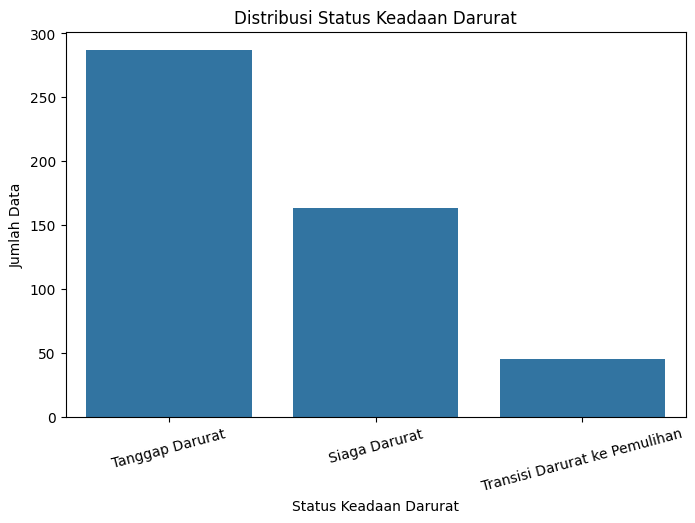

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df1,
    x="status_keadaan_darurat"
)

plt.title("Distribusi Status Keadaan Darurat")
plt.xlabel("Status Keadaan Darurat")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=15)

plt.show()

## Kesimpulan Data Understanding

Berdasarkan proses pemahaman terhadap dua dataset Kompilasi Data Kejadian dan Dampak Bencana Tahun 2025, diperoleh bahwa kedua dataset memiliki karakteristik yang berbeda tetapi saling melengkapi.

Dataset pertama, yaitu `data-mikro-status-keadaan-darurat-bencana-2025`, terdiri dari **495 data dan 17 variabel**. Dataset ini memuat informasi mengenai surat keputusan status keadaan darurat, lokasi kejadian, jenis bencana, klasifikasi bencana, status keadaan darurat, skala bencana, serta periode berlakunya status tersebut. Dataset ini ditetapkan sebagai **dataset utama** karena memiliki variabel target `status_keadaan_darurat`.

Dataset kedua, yaitu `kabupaten-yang-menetapkan-status-kedaan-darurat-tahun-2025`, terdiri dari **217 data dan 12 variabel**. Dataset ini memuat informasi agregat pada tingkat kabupaten/kota, termasuk koordinat geografis dan jumlah penetapan masing-masing status keadaan darurat. Dataset ini akan digunakan sebagai **dataset pendukung** untuk memperkaya karakteristik wilayah.

Kedua dataset memiliki atribut yang berpotensi digunakan sebagai penghubung, khususnya `id_kab`, `kabupaten`, dan `klasifikasi_bencana`. Oleh karena itu, terdapat kemungkinan untuk melakukan integrasi data setelah dilakukan pemeriksaan konsistensi atribut dan kualitas data.

### Kualitas Data

Hasil pemeriksaan missing value menunjukkan bahwa Dataset 1 memiliki:

* 42 data tanpa `id_kab`;
* 42 data tanpa `kabupaten`;
* 13 data tanpa `tautan_surat`.

Sementara itu, Dataset 2 tidak memiliki missing value pada seluruh variabelnya.

Missing value pada `id_kab` dan `kabupaten` perlu dianalisis lebih lanjut karena kedua variabel tersebut berpotensi digunakan untuk mengintegrasikan Dataset 1 dan Dataset 2.

### Distribusi Target

Variabel target yang digunakan dalam permasalahan klasifikasi adalah `status_keadaan_darurat`.

Berdasarkan hasil analisis awal terhadap 495 data, diperoleh distribusi sebagai berikut:

| Status Keadaan Darurat        |  Jumlah | Persentase |
| ----------------------------- | ------: | ---------: |
| Tanggap Darurat               |     287 |     57,98% |
| Siaga Darurat                 |     163 |     32,93% |
| Transisi Darurat ke Pemulihan |      45 |      9,09% |
| **Total**                     | **495** |   **100%** |

Distribusi tersebut menunjukkan bahwa terdapat tiga kelas target, yaitu **Tanggap Darurat**, **Siaga Darurat**, dan **Transisi Darurat ke Pemulihan**.

Kelas `Tanggap Darurat` merupakan kelas mayoritas dengan proporsi 57,98%, sedangkan `Transisi Darurat ke Pemulihan` merupakan kelas minoritas dengan proporsi 9,09%. Kondisi tersebut menunjukkan adanya **class imbalance**, sehingga ketidakseimbangan kelas perlu dipertimbangkan pada tahap pembagian data, pelatihan model, dan evaluasi.

Meskipun terdapat ketidakseimbangan kelas, ketiga kelas masih memiliki jumlah data yang dapat digunakan untuk membangun model klasifikasi. Namun, performa model tidak akan dievaluasi hanya berdasarkan accuracy karena metrik tersebut dapat memberikan gambaran yang kurang representatif ketika distribusi kelas tidak seimbang.

Oleh karena itu, metrik **precision, recall, F1-score, dan confusion matrix** akan digunakan sebagai bagian penting dalam evaluasi model.

---

## Permasalahan Machine Learning

Berdasarkan karakteristik dataset, permasalahan yang akan diselesaikan adalah **multiclass classification**.

Model akan digunakan untuk memprediksi:

`status_keadaan_darurat`

dengan tiga kemungkinan kelas:

```text
Siaga Darurat
Tanggap Darurat
Transisi Darurat ke Pemulihan
```

Fitur yang berpotensi digunakan antara lain:

* jenis bencana;
* klasifikasi bencana;
* provinsi;
* kabupaten;
* skala bencana;
* karakteristik waktu kejadian;
* durasi status keadaan darurat;
* karakteristik geografis wilayah;
* jumlah penetapan status darurat pada wilayah terkait.

Pemilihan fitur final akan dilakukan setelah proses EDA dan pemeriksaan potensi **data leakage**.

---

## Rencana Tahapan Pengembangan

Pengembangan project akan dilakukan melalui beberapa tahap berikut.

### 1. Exploratory Data Analysis (EDA)

Melakukan analisis terhadap:

* distribusi status keadaan darurat;
* distribusi jenis bencana;
* distribusi klasifikasi bencana;
* distribusi kejadian berdasarkan provinsi;
* distribusi kejadian berdasarkan kabupaten;
* pola kejadian berdasarkan waktu;
* hubungan antara variabel kategorikal dan target;
* distribusi variabel numerik;
* outlier dan anomali data.

### 2. Data Cleaning

Melakukan:

* pemeriksaan dan penanganan missing value;
* pemeriksaan data duplikat;
* pemeriksaan konsistensi kategori;
* pemeriksaan tipe data;
* validasi `id_kab` dan nama kabupaten;
* pemeriksaan konsistensi tanggal.

### 3. Data Integration

Dataset 1 dan Dataset 2 akan diintegrasikan berdasarkan atribut wilayah yang sesuai, terutama `id_kab`.

Proses integrasi akan dilakukan setelah memastikan bahwa:

* format `id_kab` konsisten;
* tidak terdapat perbedaan representasi wilayah;
* proses merge tidak menyebabkan kehilangan data secara signifikan.

### 4. Feature Engineering

Fitur baru dapat dibentuk berdasarkan informasi yang tersedia, antara lain:

* durasi status keadaan darurat;
* bulan kejadian;
* hari atau periode kejadian;
* informasi geografis;
* jumlah penetapan status darurat pada wilayah;
* fitur agregat yang relevan.

### 5. Feature Selection

Melakukan pemilihan fitur berdasarkan relevansi terhadap target serta mempertimbangkan potensi **data leakage**.

Fitur yang secara langsung muncul setelah status keadaan darurat ditetapkan tidak boleh digunakan apabila model dirancang untuk melakukan prediksi sebelum atau ketika status tersebut ditentukan.

### 6. Data Splitting

Data akan dibagi menjadi data training dan testing dengan mempertimbangkan distribusi kelas.

Karena terdapat class imbalance, proses pembagian data akan menggunakan **stratified split** agar proporsi masing-masing kelas tetap terwakili.

### 7. Model Development

Beberapa algoritma klasifikasi akan digunakan sebagai pembanding, seperti:

* Logistic Regression;
* Decision Tree;
* Random Forest;
* Gradient Boosting.

Model baseline akan dibuat terlebih dahulu sebelum dilakukan optimasi terhadap model terbaik.

### 8. Model Evaluation

Model akan dievaluasi menggunakan:

* Accuracy;
* Precision;
* Recall;
* F1-Score;
* Confusion Matrix;
* Classification Report.

F1-Score dan performa pada kelas minoritas akan menjadi perhatian penting karena dataset memiliki ketidakseimbangan kelas.

### 9. Model Selection dan Tuning

Model dengan performa terbaik akan dipilih berdasarkan hasil evaluasi dan kemudian dilakukan hyperparameter tuning.

Model final beserta preprocessing pipeline akan disimpan sebagai artifact untuk digunakan pada tahap deployment.

### 10. MLOps Implementation

Setelah model final diperoleh, project akan dikembangkan menuju pipeline MLOps yang meliputi:

```text
Machine Learning Model
        ↓
Preprocessing Pipeline
        ↓
FastAPI
        ↓
Docker
        ↓
Prometheus
        ↓
Grafana
        ↓
GitHub Actions
        ↓
CI/CD
```

Monitoring akan mencakup metrik seperti jumlah request, response time, error rate, dan distribusi hasil prediksi.

---

## Catatan Metodologis

Pada tahap berikutnya, fokus utama adalah melakukan EDA untuk memahami karakteristik data sebelum menentukan fitur yang digunakan dalam pemodelan.

Khususnya, perlu dilakukan pemeriksaan terhadap hubungan antara variabel fitur dan `status_keadaan_darurat`. Hal ini penting karena beberapa variabel dalam dataset mungkin merupakan informasi yang muncul **setelah status keadaan darurat ditetapkan**. Penggunaan variabel tersebut dapat menyebabkan data leakage dan menghasilkan performa model yang tidak mencerminkan kondisi penggunaan sebenarnya.

Oleh karena itu, pemilihan fitur akan dilakukan berdasarkan skenario prediksi yang ditentukan setelah proses EDA.


## EDA (Exploratory Data Analysis)


1. Dataset overview                  
2. Target distribution               
3. Disaster type                     
4. Disaster classification           
5. Temporal analysis                 
6. Geographic analysis               
7. Dataset relationship              
8. Duplicate/anomaly analysis        
9. Numerical distribution            
10. EDA conclusion                   

In [11]:
# ============================================
# STEP 8 - Analisis Jenis Bencana
# ============================================

print("=== JENIS BENCANA ===")
display(df1["jenis_bencana"].value_counts())

print("\n=== KLASIFIKASI BENCANA ===")
display(df1["klasifikasi_bencana"].value_counts())

=== JENIS BENCANA ===


,count
jenis_bencana,
"Banjir,Tanah longsor,Cuaca ekstrem",107
Banjir,100
"Banjir,Tanah longsor",79
"Banjir,Cuaca ekstrem,Tanah longsor,Gelombang pasang dan abrasi,Kekeringan,Kebakaran hutan dan lahan",69
Kebakaran hutan dan lahan,49
Tanah longsor,16
Cuaca ekstrem,16
"Banjir,Tanah longsor,Cuaca ekstrem,Gelombang pasang dan abrasi",10
"Kekeringan,Kebakaran hutan dan lahan",9



=== KLASIFIKASI BENCANA ===


,count
klasifikasi_bencana,
Hidrometeorologi Basah,335
Hidrometeorologi,69
Hidrometeorologi Kering,59
Geologi,18
Hidrometeorologi Basah dan Geologi,9
Non Alam,5


In [12]:
print("Jumlah jenis bencana unik:",
      df1["jenis_bencana"].nunique())

print("Jumlah klasifikasi bencana unik:",
      df1["klasifikasi_bencana"].nunique())

Jumlah jenis bencana unik: 23
Jumlah klasifikasi bencana unik: 6


In [13]:
# ============================================
# STEP 9 - Status Berdasarkan Klasifikasi Bencana
# ============================================

status_klasifikasi = pd.crosstab(
    df1["klasifikasi_bencana"],
    df1["status_keadaan_darurat"]
)

display(status_klasifikasi)

status_keadaan_darurat,Siaga Darurat,Tanggap Darurat,Transisi Darurat ke Pemulihan
klasifikasi_bencana,,,
Geologi,4,14,0
Hidrometeorologi,27,35,7
Hidrometeorologi Basah,81,218,36
Hidrometeorologi Basah dan Geologi,0,9,0
Hidrometeorologi Kering,51,6,2
Non Alam,0,5,0


In [14]:
status_klasifikasi_pct = pd.crosstab(
    df1["klasifikasi_bencana"],
    df1["status_keadaan_darurat"],
    normalize="index"
) * 100

display(status_klasifikasi_pct.round(2))

status_keadaan_darurat,Siaga Darurat,Tanggap Darurat,Transisi Darurat ke Pemulihan
klasifikasi_bencana,,,
Geologi,22.22,77.78,0.00
Hidrometeorologi,39.13,50.72,10.14
Hidrometeorologi Basah,24.18,65.07,10.75
Hidrometeorologi Basah dan Geologi,0.00,100.00,0.00
Hidrometeorologi Kering,86.44,10.17,3.39
Non Alam,0.00,100.00,0.00


<Figure size 1000x600 with 0 Axes>

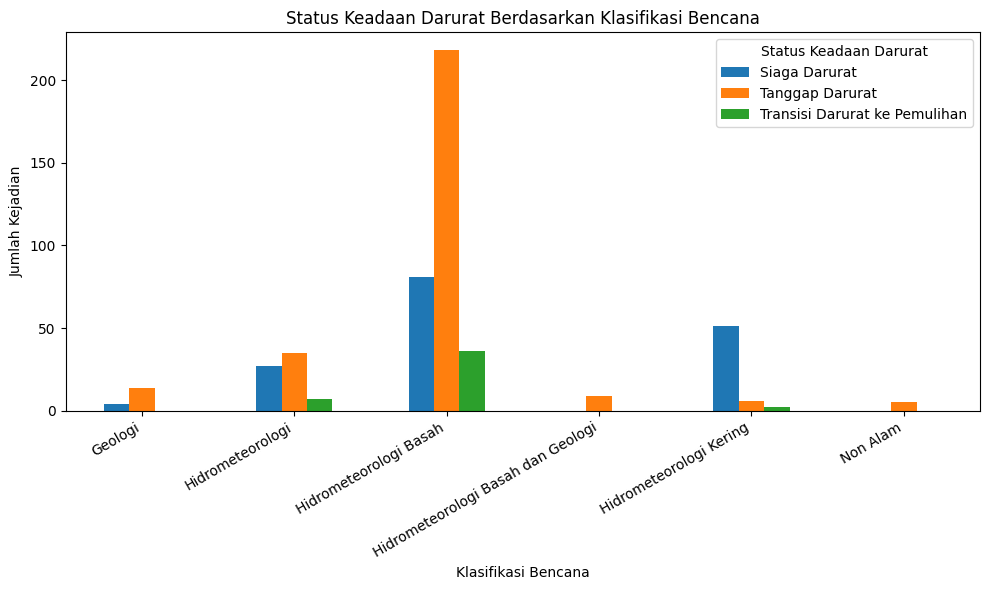

In [15]:
plt.figure(figsize=(10, 6))

status_klasifikasi.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Status Keadaan Darurat Berdasarkan Klasifikasi Bencana")
plt.xlabel("Klasifikasi Bencana")
plt.ylabel("Jumlah Kejadian")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Status Keadaan Darurat")

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# STEP 10 - Analisis Multi-Label Jenis Bencana
# ============================================

jenis_bencana_exploded = (
    df1["jenis_bencana"]
    .str.split(",")
    .explode()
    .str.strip()
)

print("Jumlah kemunculan setiap jenis bencana:")
display(jenis_bencana_exploded.value_counts())

Jumlah kemunculan setiap jenis bencana:


,count
jenis_bencana,
Banjir,379
Tanah longsor,291
Cuaca ekstrem,206
Kebakaran hutan dan lahan,127
Gelombang pasang dan abrasi,84
Kekeringan,79
Gempabumi,18
Erupsi gunung api,10
Gagal teknologi,3


In [17]:
print(
    "Jumlah jenis bencana sebenarnya:",
    jenis_bencana_exploded.nunique()
)

Jumlah jenis bencana sebenarnya: 10


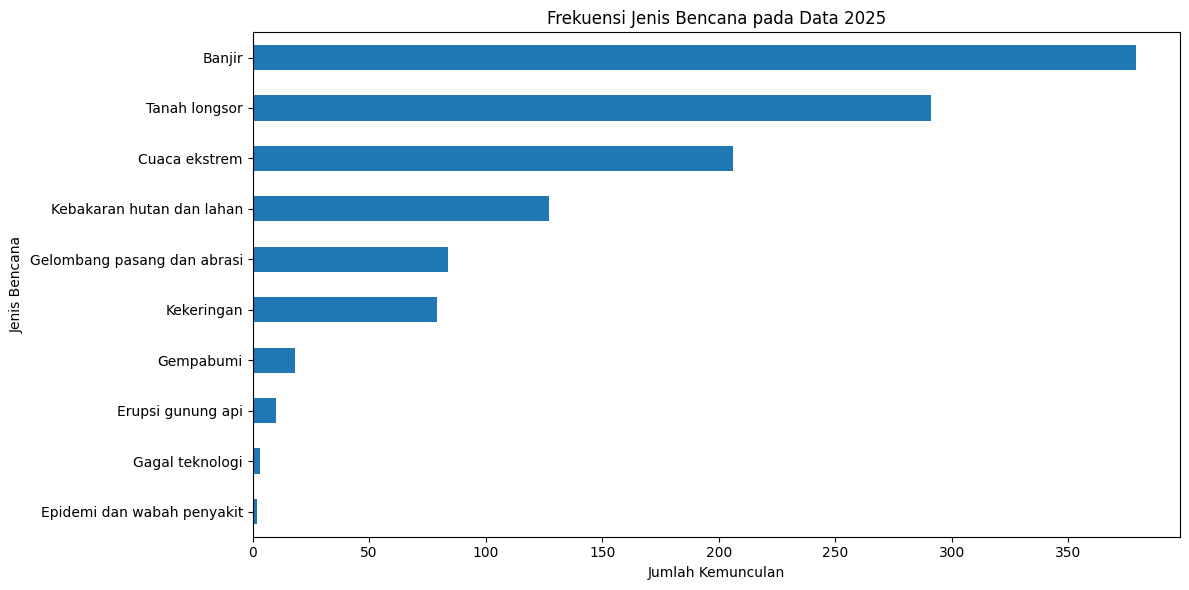

In [18]:
plt.figure(figsize=(12, 6))

jenis_bencana_exploded.value_counts().sort_values().plot(
    kind="barh",
    figsize=(12, 6)
)

plt.title("Frekuensi Jenis Bencana pada Data 2025")
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Jenis Bencana")

plt.tight_layout()
plt.show()

In [19]:
# ============================================
# STEP 12 - Jenis Bencana vs Status
# ============================================

temp = df1[[
    "jenis_bencana",
    "status_keadaan_darurat"
]].copy()

temp["jenis_bencana"] = temp["jenis_bencana"].str.split(",")

temp = temp.explode("jenis_bencana")

temp["jenis_bencana"] = temp["jenis_bencana"].str.strip()

jenis_status = pd.crosstab(
    temp["jenis_bencana"],
    temp["status_keadaan_darurat"]
)

display(jenis_status)

status_keadaan_darurat,Siaga Darurat,Tanggap Darurat,Transisi Darurat ke Pemulihan
jenis_bencana,,,
Banjir,106,231,42
Cuaca ekstrem,92,97,17
Epidemi dan wabah penyakit,0,2,0
Erupsi gunung api,3,7,0
Gagal teknologi,0,3,0
Gelombang pasang dan abrasi,38,37,9
Gempabumi,1,17,0
Kebakaran hutan dan lahan,77,41,9
Kekeringan,37,35,7


In [20]:
# ============================================
# STEP 13 — Distribusi Data Berdasarkan Bulan
# ============================================

df1["bulan_mulai"] = df1["tgl_mulai"].dt.month

jumlah_per_bulan = (
    df1["bulan_mulai"]
    .value_counts()
    .sort_index()
)

display(jumlah_per_bulan)

,count
bulan_mulai,
1,29
2,25
3,32
4,22
5,26
6,27
7,39
8,17
9,23


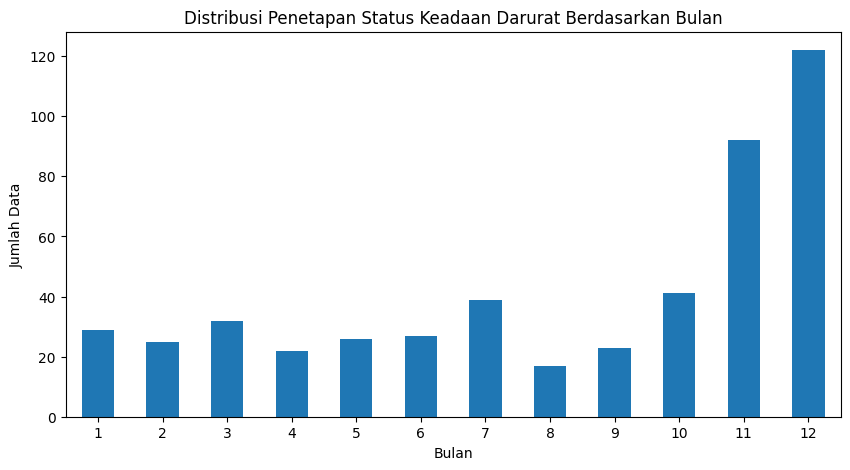

In [21]:
plt.figure(figsize=(10, 5))

jumlah_per_bulan.plot(kind="bar")

plt.title("Distribusi Penetapan Status Keadaan Darurat Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)

plt.show()

In [22]:
# ============================================
# STEP 14 — Status Keadaan Darurat Berdasarkan Bulan
# ============================================

status_per_bulan = pd.crosstab(
    df1["bulan_mulai"],
    df1["status_keadaan_darurat"]
)

display(status_per_bulan)

status_keadaan_darurat,Siaga Darurat,Tanggap Darurat,Transisi Darurat ke Pemulihan
bulan_mulai,,,
1,13,15,1
2,13,11,1
3,7,23,2
4,12,7,3
5,9,14,3
6,10,17,0
7,21,17,1
8,7,9,1
9,10,12,1


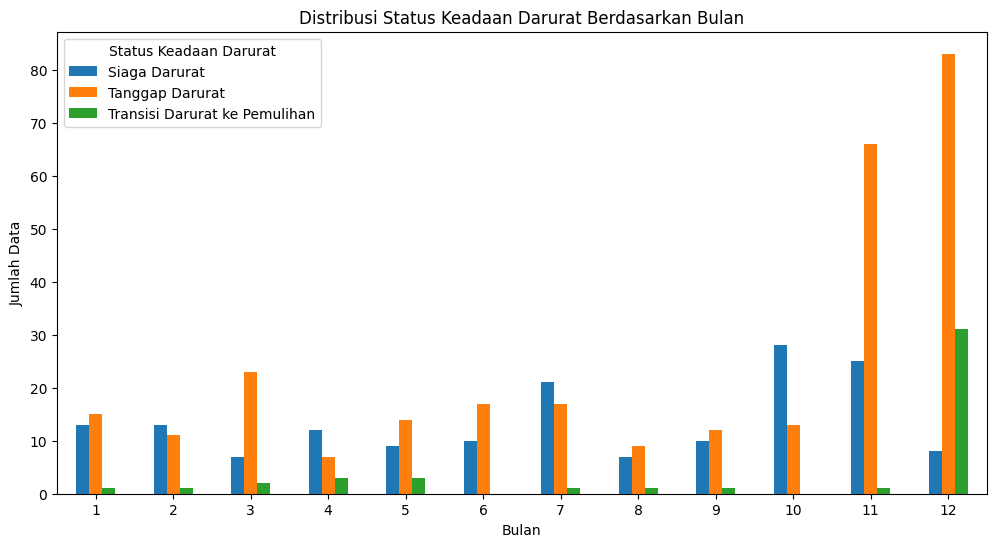

In [23]:
status_per_bulan.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribusi Status Keadaan Darurat Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.legend(title="Status Keadaan Darurat")

plt.show()

### Kesimpulan EDA Temporal

Berdasarkan analisis temporal menggunakan `tgl_mulai`, distribusi penetapan status keadaan darurat pada tahun 2025 tidak tersebar secara merata sepanjang tahun. Jumlah data relatif berada pada rentang yang lebih rendah selama Januari hingga September, kemudian meningkat pada Oktober hingga Desember. Desember memiliki jumlah data tertinggi sebanyak 122 data, sedangkan Agustus memiliki jumlah terendah sebanyak 17 data.

Analisis hubungan antara bulan dan status keadaan darurat menunjukkan adanya perbedaan distribusi status pada beberapa periode. Status Tanggap Darurat mendominasi pada November dan Desember dengan masing-masing 66 dan 83 data. Sementara itu, status Siaga Darurat relatif lebih banyak ditemukan pada Juli dan Oktober. Status Transisi Darurat ke Pemulihan merupakan kelas dengan jumlah data paling sedikit dan memiliki konsentrasi yang cukup tinggi pada Desember, yaitu sebanyak 31 data.

Hasil ini menunjukkan bahwa informasi waktu penetapan status memiliki pola yang berbeda terhadap masing-masing kelas status keadaan darurat. Oleh karena itu, informasi temporal seperti bulan dapat dipertimbangkan sebagai kandidat fitur pada tahap feature engineering. Namun, hubungan tersebut tidak diinterpretasikan sebagai hubungan sebab-akibat dan tetap akan dievaluasi kembali pada tahap pemodelan.

Selain itu, ketidakseimbangan kelas yang telah ditemukan sebelumnya kembali terlihat pada analisis temporal, khususnya pada kelas Transisi Darurat ke Pemulihan. Kondisi tersebut perlu diperhatikan pada tahap pembagian data dan evaluasi model dengan menggunakan stratified splitting serta metrik precision, recall, dan F1-score.

In [24]:
# ============================================
# STEP 15 — Distribusi Data Berdasarkan Provinsi
# ============================================

jumlah_per_provinsi = (
    df1["provinsi"]
    .value_counts()
)

display(jumlah_per_provinsi)

,count
provinsi,
Aceh,66
Sumatera Utara,62
Sumatera Barat,59
Jawa Tengah,55
Jawa Barat,31
Kalimantan Barat,27
Jawa Timur,24
Riau,21
Sumatera Selatan,12


In [25]:
# ============================================
# STEP 16 — Status Keadaan Darurat Berdasarkan Provinsi
# ============================================

status_per_provinsi = pd.crosstab(
    df1["provinsi"],
    df1["status_keadaan_darurat"]
)

display(status_per_provinsi)

status_keadaan_darurat,Siaga Darurat,Tanggap Darurat,Transisi Darurat ke Pemulihan
provinsi,,,
Aceh,3,55,8
Bali,0,6,1
Banten,3,0,0
Bengkulu,0,3,0
Daerah Istimewa Yogyakarta,6,1,0
Gorontalo,0,4,1
Jambi,4,1,0
Jawa Barat,16,14,1
Jawa Tengah,39,13,3


### Kesimpulan EDA Geografis

Analisis berdasarkan provinsi menunjukkan bahwa data penetapan status keadaan darurat tidak tersebar secara merata. Dari 495 data, terdapat 36 provinsi yang tercatat, dengan jumlah data tertinggi berasal dari Aceh, Sumatera Utara, Sumatera Barat, dan Jawa Tengah.

Distribusi status keadaan darurat juga menunjukkan variasi antarprovinsi. Beberapa provinsi seperti Aceh, Sumatera Barat, dan Sumatera Utara memiliki jumlah penetapan Tanggap Darurat yang relatif dominan, sedangkan Jawa Tengah dan Sumatera Selatan memiliki jumlah penetapan Siaga Darurat yang relatif lebih tinggi. Selain itu, beberapa provinsi memiliki jumlah observasi yang sangat sedikit sehingga distribusi statusnya belum dapat digunakan sebagai representasi umum.

Variasi tersebut menunjukkan bahwa informasi geografis berupa provinsi berpotensi menjadi salah satu fitur dalam model klasifikasi. Namun, provinsi dengan jumlah observasi yang sangat sedikit perlu diperhatikan karena dapat menghasilkan kategori yang kurang stabil pada tahap pemodelan.

Hasil analisis ini hanya menunjukkan pola distribusi dalam dataset dan tidak digunakan untuk menyimpulkan hubungan sebab-akibat antara wilayah dan status keadaan darurat.

In [26]:
# ============================================
# STEP 17 — Pemeriksaan Kesesuaian Dataset 1 & 2
# ============================================

print("Jumlah ID kabupaten unik Dataset 1:", df1["id_kab"].nunique())
print("Jumlah ID kabupaten unik Dataset 2:", df2["id_kab"].nunique())

print("\nJumlah ID kabupaten yang missing di Dataset 1:")
print(df1["id_kab"].isna().sum())

print("\nJumlah ID kabupaten Dataset 1 yang terdapat di Dataset 2:")

id_df1 = set(df1["id_kab"].dropna().astype(int))
id_df2 = set(df2["id_kab"].dropna().astype(int))

print(len(id_df1.intersection(id_df2)))

print("\nJumlah ID kabupaten Dataset 1 yang tidak terdapat di Dataset 2:")
print(len(id_df1 - id_df2))

Jumlah ID kabupaten unik Dataset 1: 217
Jumlah ID kabupaten unik Dataset 2: 217

Jumlah ID kabupaten yang missing di Dataset 1:
42

Jumlah ID kabupaten Dataset 1 yang terdapat di Dataset 2:
35

Jumlah ID kabupaten Dataset 1 yang tidak terdapat di Dataset 2:
0


In [27]:
# ============================================
# STEP 18 — Cek ID Kabupaten yang Tidak Cocok
# ============================================

id_df1 = set(df1["id_kab"].dropna().astype(int))
id_df2 = set(df2["id_kab"].dropna().astype(int))

id_tidak_cocok = sorted(id_df1 - id_df2)

print("Jumlah ID tidak cocok:", len(id_tidak_cocok))
print("\nContoh ID yang tidak cocok:")
print(id_tidak_cocok[:20])

Jumlah ID tidak cocok: 0

Contoh ID yang tidak cocok:
[]


In [28]:
# ============================================
# STEP 18B — Cek Nama Kabupaten
# ============================================

kab_df1 = set(
    df1["kabupaten"]
    .dropna()
    .astype(str)
    .str.strip()
)

kab_df2 = set(
    df2["kabupaten"]
    .dropna()
    .astype(str)
    .str.strip()
)

kab_tidak_cocok = sorted(kab_df1 - kab_df2)

print("Jumlah nama kabupaten yang tidak cocok:", len(kab_tidak_cocok))
print("\nContoh nama kabupaten yang tidak cocok:")
print(kab_tidak_cocok[:20])

Jumlah nama kabupaten yang tidak cocok: 0

Contoh nama kabupaten yang tidak cocok:
[]


In [29]:
# ============================================
# STEP 19 — Pemeriksaan Data Kabupaten Missing
# ============================================

missing_kab = df1[
    df1["id_kab"].isna() |
    df1["kabupaten"].isna()
]

print("Jumlah data dengan kabupaten/ID kabupaten missing:",
      len(missing_kab))

display(
    missing_kab[
        [
            "provinsi",
            "jenis_bencana",
            "klasifikasi_bencana",
            "status_keadaan_darurat",
            "skala_bencana",
            "tgl_mulai"
        ]
    ]
)

Jumlah data dengan kabupaten/ID kabupaten missing: 42


,provinsi,jenis_bencana,klasifikasi_bencana,status_keadaan_darurat,skala_bencana,tgl_mulai
22,Kalimantan Barat,Banjir,Hidrometeorologi Basah,Tanggap Darurat,provinsi,2025-01-24
52,Lampung,Banjir,Hidrometeorologi Basah,Tanggap Darurat,provinsi,2025-02-24
87,Riau,Kebakaran hutan dan lahan,Hidrometeorologi Kering,Siaga Darurat,provinsi,2025-04-01
90,Daerah Istimewa Yogyakarta,"Banjir,Tanah longsor,Cuaca ekstrem",Hidrometeorologi Basah,Siaga Darurat,provinsi,2025-04-09
96,Kalimantan Barat,Kebakaran hutan dan lahan,Hidrometeorologi Kering,Siaga Darurat,provinsi,2025-04-17
98,Riau,Kebakaran hutan dan lahan,Hidrometeorologi Kering,Transisi Darurat ke Pemulihan,provinsi,2025-04-18
138,Jambi,Kebakaran hutan dan lahan,Hidrometeorologi Kering,Siaga Darurat,provinsi,2025-06-02
150,Sumatera Selatan,Kebakaran hutan dan lahan,Hidrometeorologi Kering,Siaga Darurat,provinsi,2025-06-17
155,Papua Barat,"Banjir,Tanah longsor",Hidrometeorologi Basah,Tanggap Darurat,provinsi,2025-06-22
171,Papua Barat,"Banjir,Tanah longsor",Hidrometeorologi Basah,Tanggap Darurat,provinsi,2025-07-06


In [30]:
# ============================================
# STEP 20 — Pemeriksaan Duplikasi Data
# ============================================

print("Jumlah baris Dataset 1:", len(df1))

duplicate_full = df1.duplicated().sum()

print("Jumlah duplicate berdasarkan seluruh kolom:", duplicate_full)

Jumlah baris Dataset 1: 495
Jumlah duplicate berdasarkan seluruh kolom: 0


In [31]:
# ============================================
# STEP 20B — Duplikasi Berdasarkan Informasi Kejadian
# ============================================

kolom_kejadian = [
    "provinsi",
    "kabupaten",
    "jenis_bencana",
    "status_keadaan_darurat",
    "tgl_mulai"
]

duplicate_kejadian = df1.duplicated(
    subset=kolom_kejadian,
    keep=False
)

print(
    "Jumlah baris yang memiliki kombinasi kejadian sama:",
    duplicate_kejadian.sum()
)

display(
    df1.loc[
        duplicate_kejadian,
        kolom_kejadian + ["nomor_sk_status_keadaan_darurat"]
    ].sort_values(
        by=["provinsi", "tgl_mulai"]
    )
)

Jumlah baris yang memiliki kombinasi kejadian sama: 12


,provinsi,kabupaten,jenis_bencana,status_keadaan_darurat,tgl_mulai,nomor_sk_status_keadaan_darurat
415,Aceh,Aceh Tenggara,Banjir,Transisi Darurat ke Pemulihan,2025-12-11,300.1.2/288/2025
416,Aceh,Aceh Tenggara,Banjir,Transisi Darurat ke Pemulihan,2025-12-11,300.2.1/288/2025
431,Aceh,Kota Lhokseumawe,"Banjir,Tanah longsor,Cuaca ekstrem",Tanggap Darurat,2025-12-12,100.3.3.3-552 Tahun 2025
432,Aceh,Kota Lhokseumawe,"Banjir,Tanah longsor,Cuaca ekstrem",Tanggap Darurat,2025-12-12,100.3.3.3-541
268,Jawa Tengah,Banyumas,"Banjir,Tanah longsor,Cuaca ekstrem",Tanggap Darurat,2025-10-24,590 tahun 2025
269,Jawa Tengah,Banyumas,"Banjir,Tanah longsor,Cuaca ekstrem",Tanggap Darurat,2025-10-24,589 Tahun 2025
276,Jawa Tengah,Banjarnegara,"Banjir,Tanah longsor,Cuaca ekstrem",Siaga Darurat,2025-10-28,No 300.2/1010 Tahun 2025
277,Jawa Tengah,Banjarnegara,"Banjir,Tanah longsor,Cuaca ekstrem",Siaga Darurat,2025-10-28,300.2/871 Tahun 2025
363,Sumatera Utara,NaN,"Banjir,Tanah longsor,Gempabumi",Tanggap Darurat,2025-11-27,188.44/836/KPTS/2925
364,Sumatera Utara,NaN,"Banjir,Tanah longsor,Gempabumi",Tanggap Darurat,2025-11-27,188.44/836/KPTS/2025


### Kesimpulan Pemeriksaan Duplikasi

Hasil pemeriksaan menunjukkan bahwa tidak terdapat baris yang identik berdasarkan seluruh kolom pada Dataset 1. Dengan demikian, tidak ditemukan duplikasi data secara penuh yang memerlukan penghapusan.

Pemeriksaan lebih lanjut berdasarkan kombinasi provinsi, kabupaten, jenis bencana, status keadaan darurat, dan tanggal mulai menemukan 12 baris dengan kombinasi informasi kejadian yang sama. Namun, baris-baris tersebut memiliki nomor surat keputusan (SK) yang berbeda. Oleh karena itu, baris tersebut tidak langsung dikategorikan sebagai duplikasi karena dapat merepresentasikan dokumen atau penetapan administratif yang berbeda.

Berdasarkan hasil tersebut, seluruh 495 observasi dipertahankan untuk tahap selanjutnya dan tidak dilakukan penghapusan data berdasarkan pemeriksaan duplikasi.

In [32]:
# ============================================
# STEP 21 — Pemeriksaan Nomor SK
# ============================================

jumlah_sk_unik = df1["nomor_sk_status_keadaan_darurat"].nunique()

print("Jumlah data:", len(df1))
print("Jumlah nomor SK unik:", jumlah_sk_unik)
print(
    "Jumlah nomor SK yang muncul lebih dari sekali:",
    df1["nomor_sk_status_keadaan_darurat"].duplicated().sum()
)

Jumlah data: 495
Jumlah nomor SK unik: 489
Jumlah nomor SK yang muncul lebih dari sekali: 6


In [33]:
# ============================================
# STEP 21B — Detail Nomor SK Berulang
# ============================================

sk_duplicate = df1[
    df1["nomor_sk_status_keadaan_darurat"].duplicated(
        keep=False
    )
].sort_values(
    "nomor_sk_status_keadaan_darurat"
)

display(
    sk_duplicate[
        [
            "nomor_sk_status_keadaan_darurat",
            "provinsi",
            "kabupaten",
            "jenis_bencana",
            "status_keadaan_darurat",
            "tgl_mulai"
        ]
    ]
)

,nomor_sk_status_keadaan_darurat,provinsi,kabupaten,jenis_bencana,status_keadaan_darurat,tgl_mulai
84,188.45/KEP-B.MU/0084/III/2025,Sulawesi Tengah,Morowali Utara,Banjir,Tanggap Darurat,2025-03-27
88,188.45/KEP-B.MU/0084/III/2025,Sulawesi Tengah,Morowali Utara,Banjir,Tanggap Darurat,2025-04-02
267,32/360/7 Tahun 2025,Jawa Tengah,Klaten,"Banjir,Cuaca ekstrem,Tanah longsor,Gelombang p...",Siaga Darurat,2025-10-24
282,32/360/7 Tahun 2025,Jawa Tengah,Klaten,"Banjir,Cuaca ekstrem,Tanah longsor,Gelombang p...",Siaga Darurat,2025-11-01
360,613 Tahun 2025,Sumatera Utara,Deli Serdang,Banjir,Tanggap Darurat,2025-11-27
425,613 Tahun 2025,Sumatera Utara,Deli Serdang,Banjir,Transisi Darurat ke Pemulihan,2025-12-11
448,684 Tahun 2025,Banten,NaN,"Banjir,Cuaca ekstrem,Tanah longsor,Gelombang p...",Siaga Darurat,2025-12-19
494,684 Tahun 2025,Sumatera Utara,Tapanuli Utara,"Banjir,Cuaca ekstrem,Tanah longsor,Gelombang p...",Transisi Darurat ke Pemulihan,2025-12-31
98,KPAS.794/VIII/2025,Riau,NaN,Kebakaran hutan dan lahan,Transisi Darurat ke Pemulihan,2025-04-18
213,KPAS.794/VIII/2025,Riau,NaN,Kebakaran hutan dan lahan,Transisi Darurat ke Pemulihan,2025-08-19


### Kesimpulan Pemeriksaan Nomor Surat Keputusan

Pemeriksaan terhadap kolom `nomor_sk_status_keadaan_darurat` menunjukkan bahwa dari 495 observasi terdapat 489 nomor surat keputusan (SK) yang unik. Sebanyak 6 nomor SK ditemukan muncul lebih dari satu kali.

Namun, kemunculan nomor SK yang sama tidak selalu menunjukkan adanya duplikasi observasi. Beberapa nomor SK muncul pada tanggal yang berbeda, wilayah yang berbeda, atau bahkan memiliki status keadaan darurat yang berbeda. Sebagai contoh, nomor SK `613 Tahun 2025` tercatat pada dua observasi dengan status Tanggap Darurat dan Transisi Darurat ke Pemulihan.

Oleh karena itu, nomor SK tidak digunakan sebagai dasar untuk menghapus observasi. Seluruh 495 observasi tetap dipertahankan untuk tahap analisis dan pemodelan berikutnya.

In [34]:
# ============================================
# STEP 22 — Audit Kandidat Fitur & Data Leakage
# ============================================

audit_kolom = pd.DataFrame({
    "kolom": df1.columns,
    "dtype": df1.dtypes.astype(str).values,
    "missing": df1.isna().sum().values,
    "unique": df1.nunique().values
})

display(audit_kolom)

,kolom,dtype,missing,unique
0,No.,int64,0,495
1,nomor_sk_status_keadaan_darurat,object,0,489
2,negara,object,0,1
3,id_prov,int64,0,35
4,id_kab,float64,42,217
5,provinsi,object,0,35
6,kabupaten,object,42,217
7,jenis_bencana_sk,object,0,164
8,jenis_bencana,object,0,23
9,klasifikasi_bencana,object,0,6


In [35]:
# ============================================
# STEP 22B — Daftar Kolom Dataset
# ============================================

for i, kolom in enumerate(df1.columns, start=1):
    print(f"{i}. {kolom}")

1. No.
2. nomor_sk_status_keadaan_darurat
3. negara
4. id_prov
5. id_kab
6. provinsi
7. kabupaten
8. jenis_bencana_sk
9. jenis_bencana
10. klasifikasi_bencana
11. status_keadaan_darurat
12. keterangan_status
13. skala_bencana
14. tahun_penetapan
15. tgl_mulai
16. tgl_berakhir
17. tautan_surat
18. bulan_mulai


In [36]:
# ============================================
# STEP 23A — Pemeriksaan Keterangan Status
# ============================================

print("Jumlah nilai unik:", df1["keterangan_status"].nunique())
print("\nDistribusi keterangan_status:")

display(
    df1["keterangan_status"]
    .value_counts(dropna=False)
)

Jumlah nilai unik: 6

Distribusi keterangan_status:


,count
keterangan_status,
Tanggap Darurat,184
Siaga Darurat,151
Perpanjangan Tanggap Darurat,103
Transisi Darurat ke Pemulihan,43
Perpanjangan Siaga Darurat,12
Perpanjangan Transisi Darurat ke Pemulihan,2


In [37]:
# ============================================
# STEP 23B — Keterangan Status vs Target
# ============================================

keterangan_status_target = pd.crosstab(
    df1["keterangan_status"],
    df1["status_keadaan_darurat"]
)

display(keterangan_status_target)

status_keadaan_darurat,Siaga Darurat,Tanggap Darurat,Transisi Darurat ke Pemulihan
keterangan_status,,,
Perpanjangan Siaga Darurat,12,0,0
Perpanjangan Tanggap Darurat,0,103,0
Perpanjangan Transisi Darurat ke Pemulihan,0,0,2
Siaga Darurat,151,0,0
Tanggap Darurat,0,184,0
Transisi Darurat ke Pemulihan,0,0,43


In [38]:
# ============================================
# STEP 23C — Detail Keterangan Status
# ============================================

for nilai in df1["keterangan_status"].unique():
    print("=" * 60)
    print("KETERANGAN:", nilai)

    display(
        df1.loc[
            df1["keterangan_status"] == nilai,
            [
                "keterangan_status",
                "status_keadaan_darurat"
            ]
        ].drop_duplicates()
    )

KETERANGAN: Tanggap Darurat


,keterangan_status,status_keadaan_darurat
0,Tanggap Darurat,Tanggap Darurat


KETERANGAN: Siaga Darurat


,keterangan_status,status_keadaan_darurat
1,Siaga Darurat,Siaga Darurat


KETERANGAN: Perpanjangan Siaga Darurat


...

,keterangan_status,status_keadaan_darurat
4,Perpanjangan Tanggap Darurat,Tanggap Darurat


KETERANGAN: Transisi Darurat ke Pemulihan


,keterangan_status,status_keadaan_darurat
7,Transisi Darurat ke Pemulihan,Transisi Darurat ke Pemulihan


KETERANGAN: Perpanjangan Transisi Darurat ke Pemulihan


,keterangan_status,status_keadaan_darurat
416,Perpanjangan Transisi Darurat ke Pemulihan,Transisi Darurat ke Pemulihan


### Feature Selection dan Pencegahan Data Leakage

Berdasarkan hasil pemeriksaan karakteristik data, tidak seluruh kolom pada Dataset 1 digunakan sebagai fitur model. Pemilihan fitur dilakukan dengan mempertimbangkan relevansi informasi terhadap prediksi serta potensi terjadinya data leakage.

Kolom `status_keadaan_darurat` ditetapkan sebagai variabel target karena merupakan status yang akan diprediksi.

Kolom `keterangan_status` tidak digunakan sebagai fitur karena hasil analisis menunjukkan hubungan deterministik dengan target. Setiap kategori pada `keterangan_status` secara langsung merepresentasikan salah satu kategori `status_keadaan_darurat`, sehingga penggunaannya dapat menyebabkan target leakage.

Kolom `tgl_berakhir` juga tidak digunakan sebagai fitur karena merepresentasikan informasi mengenai akhir periode status yang secara temporal berada setelah atau selama periode keadaan darurat berlangsung. Informasi tersebut tidak diasumsikan tersedia pada saat prediksi dilakukan.

Kolom administratif seperti `No.`, `nomor_sk_status_keadaan_darurat`, `tautan_surat`, serta kolom identifier seperti `id_prov` dan `id_kab` tidak digunakan sebagai fitur utama model karena berfungsi sebagai identitas atau referensi administratif.

Kolom `negara` dan `tahun_penetapan` tidak digunakan karena masing-masing hanya memiliki satu nilai unik pada seluruh dataset sehingga tidak memberikan variasi informasi bagi model.

Informasi `tgl_mulai` tidak digunakan dalam bentuk tanggal mentah, tetapi dapat ditransformasikan menjadi fitur temporal seperti bulan penetapan. Sementara itu, `jenis_bencana` dipertimbangkan sebagai fitur multi-label karena satu observasi dapat memuat lebih dari satu jenis bencana.

In [39]:
# ============================================
# STEP 24 — Pemeriksaan Fitur Geografis Dataset 2
# ============================================

print("Jumlah data Dataset 2:", len(df2))

print("\nJumlah ID kabupaten unik:")
print(df2["id_kab"].nunique())

print("\nJumlah kabupaten unik:")
print(df2["kabupaten"].nunique())

print("\nMissing value:")
display(df2.isna().sum().to_frame("missing"))

print("\nStatistik latitude dan longitude:")
display(
    df2[["latitude", "longitude"]].describe()
)

Jumlah data Dataset 2: 217

Jumlah ID kabupaten unik:
217

Jumlah kabupaten unik:
217

Missing value:


,missing
no,0
id_kab,0
kabupaten,0
latitude,0
longitude,0
klasifikasi_bencana,0
jml_penetapan_siaga_darurat,0
jml_penetapan_tanggap_darurat,0
jml_penetapan_transisi_darurat_ke_pemulihan,0
jumlah_sk_siaga_darurat,0



Statistik latitude dan longitude:


,latitude,longitude
count,217.000000,217.000000
mean,-2.707359,109.726545
std,4.207406,9.955334
min,-9.827956,95.515608
25%,-7.036441,100.880702
50%,-2.545690,109.395023
75%,0.729056,114.924037
max,5.379938,139.399014


In [40]:
# ============================================
# STEP 24B — Konsistensi Koordinat
# ============================================

koordinat_per_id = (
    df2.groupby("id_kab")
    .agg(
        jumlah_latitude=("latitude", "nunique"),
        jumlah_longitude=("longitude", "nunique")
    )
)

display(
    koordinat_per_id[
        (koordinat_per_id["jumlah_latitude"] > 1) |
        (koordinat_per_id["jumlah_longitude"] > 1)
    ]
)

,jumlah_latitude,jumlah_longitude
id_kab,,


## Kesimpulan Exploratory Data Analysis

Berdasarkan hasil Exploratory Data Analysis (EDA) terhadap Dataset 1 dan Dataset 2, diperoleh beberapa karakteristik utama yang menjadi dasar untuk tahap preprocessing dan pemodelan.

Dataset 1 terdiri dari 495 observasi dengan tiga kategori `status_keadaan_darurat`, yaitu Siaga Darurat, Tanggap Darurat, dan Transisi Darurat ke Pemulihan. Distribusi target menunjukkan adanya ketidakseimbangan kelas, dengan Tanggap Darurat sebagai kelas mayoritas dan Transisi Darurat ke Pemulihan sebagai kelas minoritas.

Variabel `jenis_bencana` memiliki 23 kombinasi kategori yang terdiri atas 10 jenis bencana dasar. Oleh karena itu, variabel tersebut akan diperlakukan sebagai data multi-label pada tahap feature engineering. Variabel `klasifikasi_bencana` terdiri atas enam kategori dan menunjukkan distribusi status yang berbeda antar kategori.

Analisis temporal menggunakan `tgl_mulai` menunjukkan bahwa distribusi data tidak merata sepanjang tahun 2025. Analisis geografis juga menunjukkan variasi jumlah penetapan status antarprovinsi.

Pemeriksaan kualitas data menunjukkan tidak terdapat duplikasi berdasarkan seluruh kolom. Beberapa observasi memiliki kombinasi informasi kejadian yang sama atau nomor SK yang sama, tetapi perbedaan pada nomor SK, tanggal, wilayah, atau informasi administratif menunjukkan bahwa observasi tersebut tidak dapat langsung dianggap sebagai duplikasi dan tidak dihapus.

Pemeriksaan hubungan Dataset 1 dan Dataset 2 menunjukkan bahwa data kabupaten dapat dihubungkan menggunakan `id_kab`. Dataset 2 memiliki 217 kabupaten dengan koordinat yang lengkap dan konsisten. Sementara itu, 42 observasi pada Dataset 1 tidak memiliki `id_kab` dan `kabupaten` karena observasi tersebut memiliki `skala_bencana` pada tingkat provinsi.

Selain itu, pemeriksaan data leakage menunjukkan bahwa `keterangan_status` memiliki hubungan deterministik dengan `status_keadaan_darurat`, sehingga variabel tersebut tidak akan digunakan sebagai fitur model. Informasi administratif seperti nomor SK, tautan surat, serta identifier wilayah juga tidak digunakan sebagai fitur prediktif utama.

Hasil EDA selanjutnya digunakan sebagai dasar untuk melakukan data cleaning, data integration, dan feature engineering.

## DATA CLEANING

TAHAP 2 — DATA CLEANING

2.1 Pemeriksaan missing value

2.2 Penanganan missing value

2.3 Pemeriksaan duplicate

2.4 Pemeriksaan konsistensi kategori

2.5 Pemeriksaan tipe data

2.6 Pemeriksaan konsistensi ID

2.7 Pemeriksaan konsistensi tanggal

2.8 Membuat cleaned dataset

In [41]:
# ============================================
# STEP 25 — DATA CLEANING
# Membuat Salinan Dataset
# ============================================

df_clean = df1.copy()

print("Shape Dataset Awal :", df1.shape)
print("Shape Dataset Clean:", df_clean.shape)

Shape Dataset Awal : (495, 18)
Shape Dataset Clean: (495, 18)


In [42]:
# ============================================
# STEP 25B — Pemeriksaan Missing Value
# ============================================

missing_summary = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_percent": (
        df_clean.isna().sum() / len(df_clean) * 100
    )
})

display(
    missing_summary[
        missing_summary["missing_count"] > 0
    ].sort_values(
        "missing_count",
        ascending=False
    )
)

,missing_count,missing_percent
id_kab,42,8.484848
kabupaten,42,8.484848
tautan_surat,13,2.626263


In [43]:
# ============================================
# STEP 26 — Penanganan Missing Value
# Berdasarkan Konteks Data
# ============================================

# Cek kembali konteks missing pada id_kab dan kabupaten
missing_kab = df_clean[
    df_clean["id_kab"].isna() |
    df_clean["kabupaten"].isna()
]

print("Jumlah baris dengan id_kab/kabupaten missing:",
      len(missing_kab))

print("\nDistribusi skala_bencana pada data tersebut:")
display(
    missing_kab["skala_bencana"]
    .value_counts()
)

print("\nJumlah missing setelah keputusan cleaning:")
print("id_kab      :", df_clean["id_kab"].isna().sum())
print("kabupaten   :", df_clean["kabupaten"].isna().sum())
print("tautan_surat:", df_clean["tautan_surat"].isna().sum())

Jumlah baris dengan id_kab/kabupaten missing: 42

Distribusi skala_bencana pada data tersebut:


,count
skala_bencana,
provinsi,42



Jumlah missing setelah keputusan cleaning:
id_kab      : 42
kabupaten   : 42
tautan_surat: 13


In [44]:
# ============================================
# STEP 27 — Pemeriksaan Duplicate
# ============================================

duplicate_count = df_clean.duplicated().sum()

print("Jumlah baris duplikat:", duplicate_count)

if duplicate_count == 0:
    print("Tidak ditemukan baris duplikat.")
else:
    print("Ditemukan baris duplikat.")
    display(
        df_clean[
            df_clean.duplicated(keep=False)
        ].sort_values(
            by=df_clean.columns.tolist()
        )
    )

Jumlah baris duplikat: 0
Tidak ditemukan baris duplikat.


In [45]:
# ============================================
# STEP 28 — Pemeriksaan Konsistensi Kategori
# ============================================

categorical_columns = [
    "negara",
    "provinsi",
    "kabupaten",
    "jenis_bencana_sk",
    "jenis_bencana",
    "klasifikasi_bencana",
    "status_keadaan_darurat",
    "keterangan_status",
    "skala_bencana"
]

for col in categorical_columns:
    print("\n" + "=" * 60)
    print(f"Kolom: {col}")
    print(f"Jumlah kategori unik: {df_clean[col].nunique(dropna=True)}")
    print("Nilai unik:")

    display(
        df_clean[col]
        .value_counts(dropna=False)
        .to_frame(name="jumlah")
    )


Kolom: negara
Jumlah kategori unik: 1
Nilai unik:


,jumlah
negara,
Indonesia,495



Kolom: provinsi
Jumlah kategori unik: 35
Nilai unik:


,jumlah
provinsi,
Aceh,66
Sumatera Utara,62
Sumatera Barat,59
Jawa Tengah,55
Jawa Barat,31
Kalimantan Barat,27
Jawa Timur,24
Riau,21
Sumatera Selatan,12



Kolom: kabupaten
Jumlah kategori unik: 217
Nilai unik:


...

,jumlah
status_keadaan_darurat,
Tanggap Darurat,287
Siaga Darurat,163
Transisi Darurat ke Pemulihan,45



Kolom: keterangan_status
Jumlah kategori unik: 6
Nilai unik:


,jumlah
keterangan_status,
Tanggap Darurat,184
Siaga Darurat,151
Perpanjangan Tanggap Darurat,103
Transisi Darurat ke Pemulihan,43
Perpanjangan Siaga Darurat,12
Perpanjangan Transisi Darurat ke Pemulihan,2



Kolom: skala_bencana
Jumlah kategori unik: 2
Nilai unik:


,jumlah
skala_bencana,
kabupaten,453
provinsi,42


In [46]:
# ============================================
# STEP 29 — Pemeriksaan Tipe Data
# ============================================

dtype_summary = pd.DataFrame({
    "data_type": df_clean.dtypes.astype(str),
    "missing_count": df_clean.isna().sum(),
    "unique_count": df_clean.nunique(dropna=True)
})

display(dtype_summary)

,data_type,missing_count,unique_count
No.,int64,0,495
nomor_sk_status_keadaan_darurat,object,0,489
negara,object,0,1
id_prov,int64,0,35
id_kab,float64,42,217
provinsi,object,0,35
kabupaten,object,42,217
jenis_bencana_sk,object,0,164
jenis_bencana,object,0,23
klasifikasi_bencana,object,0,6


In [49]:
# ============================================
# STEP 30A — Pemeriksaan Nilai id_kab
# ============================================

# Tampilkan nilai id_kab yang tidak dapat dikonversi ke numerik
id_kab_numeric = pd.to_numeric(
    df_clean["id_kab"],
    errors="coerce"
)

problem_id_kab = df_clean[
    df_clean["id_kab"].notna() &
    id_kab_numeric.isna()
]

print("Jumlah nilai id_kab yang tidak dapat dikonversi:",
      len(problem_id_kab))

if len(problem_id_kab) > 0:
    display(
        problem_id_kab[
            ["id_kab", "provinsi", "kabupaten", "skala_bencana"]
        ]
    )
else:
    print("Tidak ditemukan nilai id_kab non-numerik.")

Jumlah nilai id_kab yang tidak dapat dikonversi: 0
Tidak ditemukan nilai id_kab non-numerik.


In [50]:
# ============================================
# STEP 30B — Konversi id_kab Secara Aman
# ============================================

# Konversi id_kab menjadi numerik terlebih dahulu
df_clean["id_kab"] = pd.to_numeric(
    df_clean["id_kab"],
    errors="coerce"
)

# Setelah menjadi numerik, ubah ke nullable integer
df_clean["id_kab"] = df_clean["id_kab"].astype("Int64")

# Hapus variabel turunan yang hanya digunakan untuk EDA
if "bulan_mulai" in df_clean.columns:
    df_clean = df_clean.drop(columns=["bulan_mulai"])

print("Tipe data id_kab :", df_clean["id_kab"].dtype)
print("Kolom bulan_mulai masih ada :", "bulan_mulai" in df_clean.columns)
print("Shape Dataset Clean :", df_clean.shape)

TypeError: cannot safely cast non-equivalent object to int64

In [51]:
# ============================================
# STEP 30C — Diagnosis Tipe id_kab
# ============================================

id_kab_test = pd.to_numeric(
    df_clean["id_kab"],
    errors="coerce"
)

print("Tipe asli id_kab       :", df_clean["id_kab"].dtype)
print("Tipe setelah numeric   :", id_kab_test.dtype)

print("\nJumlah missing:")
print(id_kab_test.isna().sum())

print("\nContoh 20 nilai id_kab:")
display(id_kab_test.head(20).to_frame("id_kab_test"))

print("\nTipe Python dari beberapa nilai:")
for value in id_kab_test.dropna().head(10):
    print(repr(value), "→", type(value))

Tipe asli id_kab       : float64
Tipe setelah numeric   : float64

Jumlah missing:
42

Contoh 20 nilai id_kab:


,id_kab_test
0,35.14
1,35.16
2,34.03
3,61.72
4,52.06
5,14.01
6,61.01
7,33.01
8,36.71
9,82.01



Tipe Python dari beberapa nilai:
35.14 → <class 'float'>
35.16 → <class 'float'>
34.03 → <class 'float'>
61.72 → <class 'float'>
52.06 → <class 'float'>
14.01 → <class 'float'>
61.01 → <class 'float'>
33.01 → <class 'float'>
36.71 → <class 'float'>
82.01 → <class 'float'>


In [52]:
# ============================================
# STEP 30D — Finalisasi Tipe Data
# ============================================

# id_kab dipertahankan sebagai float64
# karena kode wilayah menggunakan format seperti 35.14, 61.72, dst.
df_clean["id_kab"] = pd.to_numeric(
    df_clean["id_kab"],
    errors="coerce"
)

# Hapus variabel turunan yang dibuat khusus untuk EDA
if "bulan_mulai" in df_clean.columns:
    df_clean = df_clean.drop(columns=["bulan_mulai"])

print("Tipe data id_kab :", df_clean["id_kab"].dtype)
print("Missing id_kab   :", df_clean["id_kab"].isna().sum())
print("Kolom bulan_mulai masih ada :", "bulan_mulai" in df_clean.columns)
print("Shape Dataset Clean :", df_clean.shape)

Tipe data id_kab : float64
Missing id_kab   : 42
Kolom bulan_mulai masih ada : False
Shape Dataset Clean : (495, 17)


In [53]:
# ============================================
# STEP 31 — Validasi Konsistensi Tanggal
# ============================================

# 1. Cek tgl_berakhir sebelum tgl_mulai
tanggal_tidak_valid = df_clean[
    df_clean["tgl_berakhir"] < df_clean["tgl_mulai"]
]

# 2. Cek tahun penetapan vs tahun tgl_mulai
tahun_tidak_sesuai = df_clean[
    df_clean["tgl_mulai"].dt.year != df_clean["tahun_penetapan"]
]

# 3. Cek missing pada kolom tanggal
missing_tanggal = df_clean[
    df_clean["tgl_mulai"].isna() |
    df_clean["tgl_berakhir"].isna()
]

print("=== VALIDASI TANGGAL ===")

print("\n1. tgl_berakhir < tgl_mulai")
print("Jumlah:", len(tanggal_tidak_valid))

print("\n2. Tahun tgl_mulai != tahun_penetapan")
print("Jumlah:", len(tahun_tidak_sesuai))

print("\n3. Missing pada tgl_mulai/tgl_berakhir")
print("Jumlah:", len(missing_tanggal))

=== VALIDASI TANGGAL ===

1. tgl_berakhir < tgl_mulai
Jumlah: 8

2. Tahun tgl_mulai != tahun_penetapan
Jumlah: 0

3. Missing pada tgl_mulai/tgl_berakhir
Jumlah: 0


In [54]:
# ============================================
# STEP 31A — Investigasi Anomali Tanggal
# ============================================

kolom_tanggal = [
    "nomor_sk_status_keadaan_darurat",
    "provinsi",
    "kabupaten",
    "jenis_bencana",
    "status_keadaan_darurat",
    "keterangan_status",
    "skala_bencana",
    "tgl_mulai",
    "tgl_berakhir",
    "tahun_penetapan"
]

display(
    tanggal_tidak_valid[kolom_tanggal]
    .sort_values("tgl_mulai")
)

,nomor_sk_status_keadaan_darurat,provinsi,kabupaten,jenis_bencana,status_keadaan_darurat,keterangan_status,skala_bencana,tgl_mulai,tgl_berakhir,tahun_penetapan
131,Nomor. 105 Tahun 2025,Sulawesi Utara,Minahasa Utara,"Banjir,Tanah longsor,Cuaca ekstrem",Siaga Darurat,Siaga Darurat,kabupaten,2025-05-24,2025-05-22,2025
143,188.45/0289.BPBD/2025,Sulawesi Tengah,Donggala,Banjir,Tanggap Darurat,Perpanjangan Tanggap Darurat,kabupaten,2025-06-10,2025-06-09,2025
256,Nomor 188.45/268-BPBD/2024,Jawa Barat,Kota Sukabumi,"Banjir,Tanah longsor,Cuaca ekstrem",Siaga Darurat,Siaga Darurat,kabupaten,2025-10-08,2025-05-31,2025
283,Nomor. 362/312/HK/2024,Jawa Tengah,Wonogiri,"Banjir,Tanah longsor,Cuaca ekstrem",Siaga Darurat,Siaga Darurat,kabupaten,2025-11-01,2025-05-31,2025
289,360/Kep.475-BPBD/2024,Jawa Barat,Purwakarta,"Banjir,Tanah longsor,Cuaca ekstrem",Tanggap Darurat,Tanggap Darurat,kabupaten,2025-11-01,2025-03-31,2025
308,Nomor. 300.2/316 TAHUN 2024,Jawa Tengah,Purbalingga,"Banjir,Tanah longsor,Cuaca ekstrem",Siaga Darurat,Siaga Darurat,kabupaten,2025-11-20,2025-05-20,2025
326,Nomor. 300.2.1/844 Tahun 2024,Jawa Tengah,Kebumen,"Banjir,Tanah longsor,Cuaca ekstrem",Transisi Darurat ke Pemulihan,Transisi Darurat ke Pemulihan,kabupaten,2025-11-25,2025-05-31,2025
338,BC.05.02.A/Kep.450-BPBD/2024,Jawa Barat,Tasikmalaya,Banjir,Siaga Darurat,Siaga Darurat,kabupaten,2025-11-26,2025-05-31,2025


In [55]:
# ============================================
# STEP 31B — Dokumentasi Anomali Tanggal
# ============================================

anomali_tanggal = tanggal_tidak_valid[
    [
        "nomor_sk_status_keadaan_darurat",
        "provinsi",
        "kabupaten",
        "tgl_mulai",
        "tgl_berakhir"
    ]
].copy()

anomali_tanggal["selisih_hari"] = (
    anomali_tanggal["tgl_berakhir"] -
    anomali_tanggal["tgl_mulai"]
).dt.days

print("Jumlah anomali tanggal:", len(anomali_tanggal))

display(
    anomali_tanggal.sort_values("selisih_hari")
)

Jumlah anomali tanggal: 8


,nomor_sk_status_keadaan_darurat,provinsi,kabupaten,tgl_mulai,tgl_berakhir,selisih_hari
289,360/Kep.475-BPBD/2024,Jawa Barat,Purwakarta,2025-11-01,2025-03-31,-215
308,Nomor. 300.2/316 TAHUN 2024,Jawa Tengah,Purbalingga,2025-11-20,2025-05-20,-184
338,BC.05.02.A/Kep.450-BPBD/2024,Jawa Barat,Tasikmalaya,2025-11-26,2025-05-31,-179
326,Nomor. 300.2.1/844 Tahun 2024,Jawa Tengah,Kebumen,2025-11-25,2025-05-31,-178
283,Nomor. 362/312/HK/2024,Jawa Tengah,Wonogiri,2025-11-01,2025-05-31,-154
256,Nomor 188.45/268-BPBD/2024,Jawa Barat,Kota Sukabumi,2025-10-08,2025-05-31,-130
131,Nomor. 105 Tahun 2025,Sulawesi Utara,Minahasa Utara,2025-05-24,2025-05-22,-2
143,188.45/0289.BPBD/2025,Sulawesi Tengah,Donggala,2025-06-10,2025-06-09,-1


In [56]:
# ============================================
# STEP 32 — Validasi Akhir Dataset Clean
# ============================================

print("============================================")
print("VALIDASI AKHIR DATASET CLEAN")
print("============================================")

# 1. Shape
print("\n1. Shape Dataset")
print("Jumlah baris  :", df_clean.shape[0])
print("Jumlah kolom  :", df_clean.shape[1])

# 2. Missing Value
print("\n2. Missing Value")
print("Total missing :", df_clean.isna().sum().sum())

display(
    df_clean.isna().sum()[
        df_clean.isna().sum() > 0
    ].to_frame("missing_count")
)

# 3. Duplicate
print("\n3. Duplicate")
print("Jumlah duplicate :", df_clean.duplicated().sum())

# 4. Data Type
print("\n4. Data Type")
display(
    df_clean.dtypes.to_frame("data_type")
)

# 5. Target
print("\n5. Distribusi Target")
display(
    df_clean["status_keadaan_darurat"]
    .value_counts()
    .to_frame("jumlah")
)

# 6. Anomali tanggal
print("\n6. Anomali Tanggal")
print("Jumlah anomali :", len(anomali_tanggal))

VALIDASI AKHIR DATASET CLEAN

1. Shape Dataset
Jumlah baris  : 495
Jumlah kolom  : 17

2. Missing Value
Total missing : 97


,missing_count
id_kab,42
kabupaten,42
tautan_surat,13



3. Duplicate
Jumlah duplicate : 0

4. Data Type


,data_type
No.,int64
nomor_sk_status_keadaan_darurat,object
negara,object
id_prov,int64
id_kab,float64
provinsi,object
kabupaten,object
jenis_bencana_sk,object
jenis_bencana,object
klasifikasi_bencana,object



5. Distribusi Target


,jumlah
status_keadaan_darurat,
Tanggap Darurat,287
Siaga Darurat,163
Transisi Darurat ke Pemulihan,45



6. Anomali Tanggal
Jumlah anomali : 8


## DATA INTEGRATION


Dataset 1 + Dataset 2
    
↓

Integration berdasarkan id_kab
   
↓

Validation
   
↓

Integrated dataset

In [57]:
# ============================================
# TAHAP 3 — DATA INTEGRATION
# STEP 33 — Pemeriksaan Key Integrasi
# ============================================

print("=== PEMERIKSAAN KEY INTEGRASI ===")

print("\nDataset 1:")
print("Tipe id_kab :", df_clean["id_kab"].dtype)
print("Missing     :", df_clean["id_kab"].isna().sum())
print("Unique      :", df_clean["id_kab"].nunique())

print("\nDataset 2:")
print("Tipe id_kab :", df2["id_kab"].dtype)
print("Missing     :", df2["id_kab"].isna().sum())
print("Unique      :", df2["id_kab"].nunique())

=== PEMERIKSAAN KEY INTEGRASI ===

Dataset 1:
Tipe id_kab : float64
Missing     : 42
Unique      : 217

Dataset 2:
Tipe id_kab : float64
Missing     : 0
Unique      : 217


In [58]:
# ============================================
# TAHAP 3 — DATA INTEGRATION
# STEP 34 — Integrasi Dataset
# ============================================

df_integrated = df_clean.merge(
    df2[
        [
            "id_kab",
            "latitude",
            "longitude",
            "jml_penetapan_siaga_darurat",
            "jml_penetapan_tanggap_darurat",
            "jml_penetapan_transisi_darurat_ke_pemulihan",
            "jumlah_sk_siaga_darurat",
            "jumlah_sk_tanggap_darurat",
            "jumlah_sk_transisi_darurat_ke_pemulihan"
        ]
    ],
    on="id_kab",
    how="left"
)

print("Shape Dataset 1 :", df_clean.shape)
print("Shape Dataset 2 :", df2.shape)
print("Shape Dataset Terintegrasi :", df_integrated.shape)

Shape Dataset 1 : (495, 17)
Shape Dataset 2 : (217, 12)
Shape Dataset Terintegrasi : (495, 25)


In [59]:
# ============================================
# TAHAP 3 — DATA INTEGRATION
# STEP 35 — Validasi Hasil Integrasi
# ============================================

print("=== VALIDASI HASIL INTEGRASI ===")

print("\nJumlah baris :", len(df_integrated))
print("Jumlah kolom :", len(df_integrated.columns))

print("\nKolom Dataset Terintegrasi:")
print(df_integrated.columns.tolist())

print("\nMissing value pada kolom hasil integrasi:")
print(
    df_integrated[
        [
            "latitude",
            "longitude",
            "jml_penetapan_siaga_darurat",
            "jml_penetapan_tanggap_darurat",
            "jml_penetapan_transisi_darurat_ke_pemulihan",
            "jumlah_sk_siaga_darurat",
            "jumlah_sk_tanggap_darurat",
            "jumlah_sk_transisi_darurat_ke_pemulihan"
        ]
    ].isna().sum()
)

=== VALIDASI HASIL INTEGRASI ===

Jumlah baris : 495
Jumlah kolom : 25

Kolom Dataset Terintegrasi:
['No.', 'nomor_sk_status_keadaan_darurat', 'negara', 'id_prov', 'id_kab', 'provinsi', 'kabupaten', 'jenis_bencana_sk', 'jenis_bencana', 'klasifikasi_bencana', 'status_keadaan_darurat', 'keterangan_status', 'skala_bencana', 'tahun_penetapan', 'tgl_mulai', 'tgl_berakhir', 'tautan_surat', 'latitude', 'longitude', 'jml_penetapan_siaga_darurat', 'jml_penetapan_tanggap_darurat', 'jml_penetapan_transisi_darurat_ke_pemulihan', 'jumlah_sk_siaga_darurat', 'jumlah_sk_tanggap_darurat', 'jumlah_sk_transisi_darurat_ke_pemulihan']

Missing value pada kolom hasil integrasi:
latitude                                       42
longitude                                      42
jml_penetapan_siaga_darurat                    42
jml_penetapan_tanggap_darurat                  42
jml_penetapan_transisi_darurat_ke_pemulihan    42
jumlah_sk_siaga_darurat                        42
jumlah_sk_tanggap_darurat          

## FEATURE ENGINEERING

jenis_bencana

↓

multi-hot encoding

tgl_mulai

↓

bulan / fitur waktu

Dataset 2

↓

fitur geografis

historical information

↓

fitur agregat (jika leakage-safe)

In [60]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 36 — Durasi Status
# ============================================

df_integrated["durasi_status_hari"] = (
    df_integrated["tgl_berakhir"] - df_integrated["tgl_mulai"]
).dt.days

print("Fitur durasi_status_hari berhasil dibuat.")

print("\nContoh data:")
print(
    df_integrated[
        ["tgl_mulai", "tgl_berakhir", "durasi_status_hari"]
    ].head()
)

Fitur durasi_status_hari berhasil dibuat.

Contoh data:
   tgl_mulai tgl_berakhir  durasi_status_hari
0 2025-01-01   2025-05-31                 150
1 2025-01-01   2025-05-31                 150
2 2025-01-03   2025-03-31                  87
3 2025-01-06   2025-04-08                  92
4 2025-01-07   2025-01-20                  13


In [61]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 37 — Pemeriksaan Durasi Status
# ============================================

print("=== PEMERIKSAAN DURASI STATUS ===")

print("\nStatistik durasi:")
print(df_integrated["durasi_status_hari"].describe())

print("\nJumlah durasi negatif:",
      (df_integrated["durasi_status_hari"] < 0).sum())

print("\nJumlah durasi nol:",
      (df_integrated["durasi_status_hari"] == 0).sum())

print("\nJumlah durasi positif:",
      (df_integrated["durasi_status_hari"] > 0).sum())

=== PEMERIKSAAN DURASI STATUS ===

Statistik durasi:
count    495.000000
mean      64.725253
std       87.434587
min     -215.000000
25%       13.000000
50%       14.000000
75%      104.000000
max      528.000000
Name: durasi_status_hari, dtype: float64

Jumlah durasi negatif: 8

Jumlah durasi nol: 3

Jumlah durasi positif: 484


In [62]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 38 — Fitur Waktu
# ============================================

df_integrated["bulan_mulai"] = df_integrated["tgl_mulai"].dt.month
df_integrated["kuartal_mulai"] = df_integrated["tgl_mulai"].dt.quarter

print("Fitur waktu berhasil dibuat.")

print("\nContoh data:")
print(
    df_integrated[
        ["tgl_mulai", "bulan_mulai", "kuartal_mulai"]
    ].head()
)

Fitur waktu berhasil dibuat.

Contoh data:
   tgl_mulai  bulan_mulai  kuartal_mulai
0 2025-01-01            1              1
1 2025-01-01            1              1
2 2025-01-03            1              1
3 2025-01-06            1              1
4 2025-01-07            1              1


In [63]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 39 — Fitur Geografis
# ============================================

print("=== FITUR GEOGRAFIS ===")

print("\nTipe data:")
print(df_integrated[["latitude", "longitude"]].dtypes)

print("\nContoh data:")
print(
    df_integrated[
        ["provinsi", "kabupaten", "latitude", "longitude"]
    ].head()
)

=== FITUR GEOGRAFIS ===

Tipe data:
latitude     float64
longitude    float64
dtype: object

Contoh data:
                     provinsi        kabupaten  latitude   longitude
0                  Jawa Timur         Pasuruan -7.742918  112.831740
1                  Jawa Timur        Mojokerto -7.549868  112.485249
2  Daerah Istimewa Yogyakarta      Gunungkidul -7.994237  110.612061
3            Kalimantan Barat  Kota Singkawang  0.898524  109.034892
4         Nusa Tenggara Barat             Bima -8.474764  118.618620


In [64]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 40 — Jumlah Kejadian Sebelumnya
# ============================================

df_integrated = df_integrated.sort_values(
    ["id_kab", "tgl_mulai"]
).copy()

df_integrated["jumlah_kejadian_sebelumnya"] = (
    df_integrated.groupby("id_kab").cumcount()
)

print("Fitur jumlah_kejadian_sebelumnya berhasil dibuat.")

print("\nContoh data:")
print(
    df_integrated[
        [
            "id_kab",
            "kabupaten",
            "tgl_mulai",
            "jumlah_kejadian_sebelumnya"
        ]
    ].head(10)
)

Fitur jumlah_kejadian_sebelumnya berhasil dibuat.

Contoh data:
     id_kab      kabupaten  tgl_mulai  jumlah_kejadian_sebelumnya
215   11.01   Aceh Selatan 2025-08-23                         0.0
316   11.01   Aceh Selatan 2025-11-24                         1.0
428   11.01   Aceh Selatan 2025-12-12                         2.0
351   11.02  Aceh Tenggara 2025-11-27                         0.0
415   11.02  Aceh Tenggara 2025-12-11                         1.0
416   11.02  Aceh Tenggara 2025-12-11                         2.0
317   11.03     Aceh Timur 2025-11-24                         0.0
387   11.03     Aceh Timur 2025-12-08                         1.0
452   11.03     Aceh Timur 2025-12-22                         2.0
324   11.04    Aceh Tengah 2025-11-25                         0.0


In [65]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 41 — Validasi Historical Feature
# ============================================

print("=== VALIDASI JUMLAH KEJADIAN SEBELUMNYA ===")

missing_id = df_integrated["id_kab"].isna()

print("\nJumlah data dengan id_kab kosong:",
      missing_id.sum())

print("\nNilai jumlah_kejadian_sebelumnya pada id_kab kosong:")
print(
    df_integrated.loc[
        missing_id,
        "jumlah_kejadian_sebelumnya"
    ].value_counts(dropna=False)
)

print("\nContoh data:")
print(
    df_integrated.loc[
        missing_id,
        [
            "provinsi",
            "kabupaten",
            "skala_bencana",
            "tgl_mulai",
            "jumlah_kejadian_sebelumnya"
        ]
    ].head(10)
)

=== VALIDASI JUMLAH KEJADIAN SEBELUMNYA ===

Jumlah data dengan id_kab kosong: 42

Nilai jumlah_kejadian_sebelumnya pada id_kab kosong:
jumlah_kejadian_sebelumnya
NaN    42
Name: count, dtype: int64

Contoh data:
                       provinsi kabupaten skala_bencana  tgl_mulai  \
22             Kalimantan Barat       NaN      provinsi 2025-01-24   
52                      Lampung       NaN      provinsi 2025-02-24   
87                         Riau       NaN      provinsi 2025-04-01   
90   Daerah Istimewa Yogyakarta       NaN      provinsi 2025-04-09   
96             Kalimantan Barat       NaN      provinsi 2025-04-17   
98                         Riau       NaN      provinsi 2025-04-18   
138                       Jambi       NaN      provinsi 2025-06-02   
150            Sumatera Selatan       NaN      provinsi 2025-06-17   
155                 Papua Barat       NaN      provinsi 2025-06-22   
171                 Papua Barat       NaN      provinsi 2025-07-06   

     jumlah_keja

In [66]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 42 — Jarak Waktu Antar Kejadian
# ============================================

df_integrated["hari_sejak_kejadian_sebelumnya"] = (
    df_integrated
    .groupby("id_kab")["tgl_mulai"]
    .diff()
    .dt.days
)

print("Fitur hari_sejak_kejadian_sebelumnya berhasil dibuat.")

print("\nContoh data:")
print(
    df_integrated[
        [
            "id_kab",
            "kabupaten",
            "tgl_mulai",
            "jumlah_kejadian_sebelumnya",
            "hari_sejak_kejadian_sebelumnya"
        ]
    ].head(15)
)

Fitur hari_sejak_kejadian_sebelumnya berhasil dibuat.

Contoh data:
     id_kab      kabupaten  tgl_mulai  jumlah_kejadian_sebelumnya  \
215   11.01   Aceh Selatan 2025-08-23                         0.0   
316   11.01   Aceh Selatan 2025-11-24                         1.0   
428   11.01   Aceh Selatan 2025-12-12                         2.0   
351   11.02  Aceh Tenggara 2025-11-27                         0.0   
415   11.02  Aceh Tenggara 2025-12-11                         1.0   
416   11.02  Aceh Tenggara 2025-12-11                         2.0   
317   11.03     Aceh Timur 2025-11-24                         0.0   
387   11.03     Aceh Timur 2025-12-08                         1.0   
452   11.03     Aceh Timur 2025-12-22                         2.0   
324   11.04    Aceh Tengah 2025-11-25                         0.0   
396   11.04    Aceh Tengah 2025-12-09                         1.0   
440   11.04    Aceh Tengah 2025-12-16                         2.0   
461   11.04    Aceh Tengah 2025-12-

In [67]:
# ============================================
# TAHAP 4 — FEATURE ENGINEERING
# STEP 43 — Inventarisasi Fitur
# ============================================

print("=== DAFTAR KOLOM DATASET TERINTEGRASI ===")

for i, col in enumerate(df_integrated.columns, start=1):
    print(f"{i:2}. {col}")

=== DAFTAR KOLOM DATASET TERINTEGRASI ===
 1. No.
 2. nomor_sk_status_keadaan_darurat
 3. negara
 4. id_prov
 5. id_kab
 6. provinsi
 7. kabupaten
 8. jenis_bencana_sk
 9. jenis_bencana
10. klasifikasi_bencana
11. status_keadaan_darurat
12. keterangan_status
13. skala_bencana
14. tahun_penetapan
15. tgl_mulai
16. tgl_berakhir
17. tautan_surat
18. latitude
19. longitude
20. jml_penetapan_siaga_darurat
21. jml_penetapan_tanggap_darurat
22. jml_penetapan_transisi_darurat_ke_pemulihan
23. jumlah_sk_siaga_darurat
24. jumlah_sk_tanggap_darurat
25. jumlah_sk_transisi_darurat_ke_pemulihan
26. durasi_status_hari
27. bulan_mulai
28. kuartal_mulai
29. jumlah_kejadian_sebelumnya
30. hari_sejak_kejadian_sebelumnya


## FEATURE SELECTION

Semua kandidat fitur

↓

Leakage check

↓

Relevance

↓

Final features

In [68]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 44 — Kandidat Fitur
# ============================================

candidate_features = [
    "jenis_bencana",
    "klasifikasi_bencana",
    "skala_bencana",
    "provinsi",
    "kabupaten",
    "latitude",
    "longitude",
    "bulan_mulai",
    "kuartal_mulai",
    "jumlah_kejadian_sebelumnya",
    "hari_sejak_kejadian_sebelumnya"
]

target = "status_keadaan_darurat"

df_model = df_integrated[candidate_features + [target]].copy()

print("Jumlah fitur kandidat :", len(candidate_features))
print("Jumlah kolom total    :", len(df_model.columns))
print("Jumlah baris          :", len(df_model))

print("\nFitur kandidat:")
for i, col in enumerate(candidate_features, start=1):
    print(f"{i:2}. {col}")

print("\nTarget:")
print(target)

Jumlah fitur kandidat : 11
Jumlah kolom total    : 12
Jumlah baris          : 495

Fitur kandidat:
 1. jenis_bencana
 2. klasifikasi_bencana
 3. skala_bencana
 4. provinsi
 5. kabupaten
 6. latitude
 7. longitude
 8. bulan_mulai
 9. kuartal_mulai
10. jumlah_kejadian_sebelumnya
11. hari_sejak_kejadian_sebelumnya

Target:
status_keadaan_darurat


In [69]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 45 — Missing Value Kandidat Fitur
# ============================================

print("=== MISSING VALUE KANDIDAT FITUR ===")

missing_features = df_model[candidate_features].isna().sum()

missing_table = pd.DataFrame({
    "jumlah_missing": missing_features,
    "persentase": (missing_features / len(df_model) * 100).round(2)
})

print(missing_table)


=== MISSING VALUE KANDIDAT FITUR ===
                                jumlah_missing  persentase
jenis_bencana                                0        0.00
klasifikasi_bencana                          0        0.00
skala_bencana                                0        0.00
provinsi                                     0        0.00
kabupaten                                   42        8.48
latitude                                    42        8.48
longitude                                   42        8.48
bulan_mulai                                  0        0.00
kuartal_mulai                                0        0.00
jumlah_kejadian_sebelumnya                  42        8.48
hari_sejak_kejadian_sebelumnya             259       52.32


In [70]:
print("\nMissing pada target:")
print(df_model[target].isna().sum())


Missing pada target:
0


In [71]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 46 — Indikator Historical Feature
# ============================================

df_model["ada_kejadian_sebelumnya"] = (
    df_model["hari_sejak_kejadian_sebelumnya"].notna().astype(int)
)

print("Fitur ada_kejadian_sebelumnya berhasil dibuat.")

print("\nDistribusi fitur:")
print(
    df_model["ada_kejadian_sebelumnya"]
    .value_counts()
    .sort_index()
)

print("\nContoh:")
print(
    df_model[
        [
            "jumlah_kejadian_sebelumnya",
            "hari_sejak_kejadian_sebelumnya",
            "ada_kejadian_sebelumnya"
        ]
    ].head(15)
)

Fitur ada_kejadian_sebelumnya berhasil dibuat.

Distribusi fitur:
ada_kejadian_sebelumnya
0    259
1    236
Name: count, dtype: int64

Contoh:
     jumlah_kejadian_sebelumnya  hari_sejak_kejadian_sebelumnya  \
215                         0.0                             NaN   
316                         1.0                            93.0   
428                         2.0                            18.0   
351                         0.0                             NaN   
415                         1.0                            14.0   
416                         2.0                             0.0   
317                         0.0                             NaN   
387                         1.0                            14.0   
452                         2.0                            14.0   
324                         0.0                             NaN   
396                         1.0                            14.0   
440                         2.0                      

In [72]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 47 — Koreksi Indikator Historical Feature
# ============================================

# Data tanpa kabupaten berarti riwayat kabupaten tidak diketahui
df_model.loc[
    df_model["kabupaten"].isna(),
    "ada_kejadian_sebelumnya"
] = float("nan")

print("Distribusi fitur setelah koreksi:")
print(
    df_model["ada_kejadian_sebelumnya"]
    .value_counts(dropna=False)
    .sort_index()
)

Distribusi fitur setelah koreksi:
ada_kejadian_sebelumnya
0.0    217
1.0    236
NaN     42
Name: count, dtype: int64


In [73]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 48 — Finalisasi Kandidat Fitur
# ============================================

candidate_features = [
    "jenis_bencana",
    "klasifikasi_bencana",
    "skala_bencana",
    "provinsi",
    "kabupaten",
    "latitude",
    "longitude",
    "bulan_mulai",
    "kuartal_mulai",
    "jumlah_kejadian_sebelumnya",
    "hari_sejak_kejadian_sebelumnya",
    "ada_kejadian_sebelumnya"
]

target = "status_keadaan_darurat"

df_model = df_model[
    candidate_features + [target]
].copy()

print("Jumlah fitur kandidat :", len(candidate_features))
print("Jumlah kolom total    :", len(df_model.columns))
print("Jumlah baris          :", len(df_model))

print("\nFitur kandidat:")
for i, col in enumerate(candidate_features, start=1):
    print(f"{i:2}. {col}")

Jumlah fitur kandidat : 12
Jumlah kolom total    : 13
Jumlah baris          : 495

Fitur kandidat:
 1. jenis_bencana
 2. klasifikasi_bencana
 3. skala_bencana
 4. provinsi
 5. kabupaten
 6. latitude
 7. longitude
 8. bulan_mulai
 9. kuartal_mulai
10. jumlah_kejadian_sebelumnya
11. hari_sejak_kejadian_sebelumnya
12. ada_kejadian_sebelumnya


In [74]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 49 — Validasi Historical Feature
# ============================================

same_date = (
    df_integrated
    .dropna(subset=["id_kab"])
    .groupby(["id_kab", "tgl_mulai"])
    .size()
    .reset_index(name="jumlah_observasi")
)

same_date = same_date[
    same_date["jumlah_observasi"] > 1
]

print("=== OBSERVASI DENGAN id_kab DAN TANGGAL YANG SAMA ===")

print("Jumlah kombinasi id_kab + tgl_mulai yang memiliki >1 observasi:",
      len(same_date))

print("\nContoh:")
print(same_date.head(20))

=== OBSERVASI DENGAN id_kab DAN TANGGAL YANG SAMA ===
Jumlah kombinasi id_kab + tgl_mulai yang memiliki >1 observasi: 5

Contoh:
     id_kab  tgl_mulai  jumlah_observasi
4     11.02 2025-12-11                 2
54    11.73 2025-12-12                 2
243   33.01 2025-11-14                 2
245   33.02 2025-10-24                 2
248   33.04 2025-10-28                 2


In [76]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 50 — Perbaikan Historical Feature
# ============================================

# Urutkan berdasarkan kabupaten dan tanggal kejadian
df_integrated = df_integrated.sort_values(
    ["id_kab", "tgl_mulai"]
).copy()

# Identifikasi tanggal kejadian baru
# 1 = tanggal berbeda dari observasi sebelumnya
# 0 = tanggal yang sama
df_integrated["tanggal_kejadian_baru"] = (
    df_integrated.groupby("id_kab")["tgl_mulai"]
    .transform(lambda x: x.ne(x.shift()).astype(int))
)

# Jumlah kejadian berbeda yang terjadi sebelum kejadian saat ini
df_integrated["jumlah_kejadian_sebelumnya"] = (
    df_integrated.groupby("id_kab")["tanggal_kejadian_baru"]
    .cumsum()
    - 1
)

# Ambil tanggal kejadian sebelumnya yang berbeda
df_integrated["tgl_kejadian_sebelumnya"] = (
    df_integrated["tgl_mulai"]
    .where(df_integrated["tanggal_kejadian_baru"] == 1)
    .groupby(df_integrated["id_kab"])
    .ffill()
    .groupby(df_integrated["id_kab"])
    .shift()
)

# Jarak hari dari kejadian sebelumnya
df_integrated["hari_sejak_kejadian_sebelumnya"] = (
    df_integrated["tgl_mulai"]
    - df_integrated["tgl_kejadian_sebelumnya"]
).dt.days

# Kabupaten tanpa id_kab:
# riwayat kejadian sebelumnya dianggap tidak diketahui
df_integrated.loc[
    df_integrated["id_kab"].isna(),
    [
        "jumlah_kejadian_sebelumnya",
        "hari_sejak_kejadian_sebelumnya"
    ]
] = float("nan")

# Hapus kolom bantu
df_integrated = df_integrated.drop(
    columns=[
        "tanggal_kejadian_baru",
        "tgl_kejadian_sebelumnya"
    ]
)

print("Historical feature berhasil diperbarui.")

print("\nContoh:")
print(
    df_integrated[
        [
            "id_kab",
            "tgl_mulai",
            "jumlah_kejadian_sebelumnya",
            "hari_sejak_kejadian_sebelumnya"
        ]
    ].head(15)
)

Historical feature berhasil diperbarui.

Contoh:
     id_kab  tgl_mulai  jumlah_kejadian_sebelumnya  \
215   11.01 2025-08-23                         0.0   
316   11.01 2025-11-24                         1.0   
428   11.01 2025-12-12                         2.0   
351   11.02 2025-11-27                         0.0   
415   11.02 2025-12-11                         1.0   
416   11.02 2025-12-11                         1.0   
317   11.03 2025-11-24                         0.0   
387   11.03 2025-12-08                         1.0   
452   11.03 2025-12-22                         2.0   
324   11.04 2025-11-25                         0.0   
396   11.04 2025-12-09                         1.0   
440   11.04 2025-12-16                         2.0   
461   11.04 2025-12-23                         3.0   
488   11.04 2025-12-29                         4.0   
225   11.05 2025-09-12                         0.0   

     hari_sejak_kejadian_sebelumnya  
215                             NaN  
316       

In [77]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 51 — Sinkronisasi Jarak Kejadian
# ============================================

# Buat tanggal kejadian unik per kabupaten
tanggal_unik = (
    df_integrated[
        ["id_kab", "tgl_mulai"]
    ]
    .drop_duplicates()
    .sort_values(["id_kab", "tgl_mulai"])
    .copy()
)

# Hitung jarak antar tanggal kejadian unik
tanggal_unik["hari_sejak_kejadian_sebelumnya"] = (
    tanggal_unik
    .groupby("id_kab")["tgl_mulai"]
    .diff()
    .dt.days
)

# Gabungkan kembali ke seluruh observasi
df_integrated = df_integrated.drop(
    columns=["hari_sejak_kejadian_sebelumnya"]
)

df_integrated = df_integrated.merge(
    tanggal_unik,
    on=["id_kab", "tgl_mulai"],
    how="left"
)

# Untuk kabupaten tanpa id_kab, nilai tetap tidak diketahui
df_integrated.loc[
    df_integrated["id_kab"].isna(),
    "hari_sejak_kejadian_sebelumnya"
] = float("nan")

print("Jarak kejadian sebelumnya berhasil disinkronkan.")

print("\nContoh:")
print(
    df_integrated[
        [
            "id_kab",
            "tgl_mulai",
            "jumlah_kejadian_sebelumnya",
            "hari_sejak_kejadian_sebelumnya"
        ]
    ].head(15)
)

Jarak kejadian sebelumnya berhasil disinkronkan.

Contoh:
    id_kab  tgl_mulai  jumlah_kejadian_sebelumnya  \
0    11.01 2025-08-23                         0.0   
1    11.01 2025-11-24                         1.0   
2    11.01 2025-12-12                         2.0   
3    11.02 2025-11-27                         0.0   
4    11.02 2025-12-11                         1.0   
5    11.02 2025-12-11                         1.0   
6    11.03 2025-11-24                         0.0   
7    11.03 2025-12-08                         1.0   
8    11.03 2025-12-22                         2.0   
9    11.04 2025-11-25                         0.0   
10   11.04 2025-12-09                         1.0   
11   11.04 2025-12-16                         2.0   
12   11.04 2025-12-23                         3.0   
13   11.04 2025-12-29                         4.0   
14   11.05 2025-09-12                         0.0   

    hari_sejak_kejadian_sebelumnya  
0                              NaN  
1                  

In [79]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 52 — Sinkronisasi df_model
# ============================================

candidate_features = [
    "jenis_bencana",
    "klasifikasi_bencana",
    "skala_bencana",
    "provinsi",
    "kabupaten",
    "latitude",
    "longitude",
    "bulan_mulai",
    "kuartal_mulai",
    "jumlah_kejadian_sebelumnya",
    "hari_sejak_kejadian_sebelumnya",
    "ada_kejadian_sebelumnya"
]

target = "status_keadaan_darurat"

# Ambil fitur selain ada_kejadian_sebelumnya
base_features = [
    col for col in candidate_features
    if col != "ada_kejadian_sebelumnya"
]

df_model = df_integrated[
    base_features + [target]
].copy()

# Buat indikator apakah terdapat kejadian sebelumnya
df_model["ada_kejadian_sebelumnya"] = (
    df_model["hari_sejak_kejadian_sebelumnya"]
    .notna()
    .astype(float)
)

# Kabupaten yang tidak diketahui tetap diberi NaN
df_model.loc[
    df_model["kabupaten"].isna(),
    "ada_kejadian_sebelumnya"
] = float("nan")

# Susun kembali urutan kolom
df_model = df_model[
    candidate_features + [target]
]

print("df_model berhasil disinkronkan.")

print("\nShape:")
print(df_model.shape)

print("\nJumlah fitur:", len(candidate_features))

print("\nDistribusi ada_kejadian_sebelumnya:")
print(
    df_model["ada_kejadian_sebelumnya"]
    .value_counts(dropna=False)
)

print("\nContoh historical feature:")
print(
    df_model[
        [
            "jumlah_kejadian_sebelumnya",
            "hari_sejak_kejadian_sebelumnya",
            "ada_kejadian_sebelumnya"
        ]
    ].head(15)
)

df_model berhasil disinkronkan.

Shape:
(495, 13)

Jumlah fitur: 12

Distribusi ada_kejadian_sebelumnya:
ada_kejadian_sebelumnya
1.0    234
0.0    219
NaN     42
Name: count, dtype: int64

Contoh historical feature:
    jumlah_kejadian_sebelumnya  hari_sejak_kejadian_sebelumnya  \
0                          0.0                             NaN   
1                          1.0                            93.0   
2                          2.0                            18.0   
3                          0.0                             NaN   
4                          1.0                            14.0   
5                          1.0                            14.0   
6                          0.0                             NaN   
7                          1.0                            14.0   
8                          2.0                            14.0   
9                          0.0                             NaN   
10                         1.0                            

In [80]:
# ============================================
# TAHAP 5 — FEATURE SELECTION
# STEP 53 — Penetapan Fitur Final
# ============================================

final_features = [
    "jenis_bencana",
    "klasifikasi_bencana",
    "skala_bencana",
    "provinsi",
    "kabupaten",
    "latitude",
    "longitude",
    "bulan_mulai",
    "kuartal_mulai",
    "jumlah_kejadian_sebelumnya",
    "hari_sejak_kejadian_sebelumnya",
    "ada_kejadian_sebelumnya"
]

target = "status_keadaan_darurat"

print("=== FITUR FINAL MODEL ===")

for i, feature in enumerate(final_features, start=1):
    print(f"{i:2}. {feature}")

print("\nJumlah fitur final :", len(final_features))
print("Target             :", target)
print("Jumlah data        :", len(df_model))

=== FITUR FINAL MODEL ===
 1. jenis_bencana
 2. klasifikasi_bencana
 3. skala_bencana
 4. provinsi
 5. kabupaten
 6. latitude
 7. longitude
 8. bulan_mulai
 9. kuartal_mulai
10. jumlah_kejadian_sebelumnya
11. hari_sejak_kejadian_sebelumnya
12. ada_kejadian_sebelumnya

Jumlah fitur final : 12
Target             : status_keadaan_darurat
Jumlah data        : 495


## DATA SPLITTING

Dataset

↓

Train / Test

↓

Stratified

In [81]:
# ============================================
# TAHAP 6 — DATA SPLITTING
# STEP 54 — Memisahkan Feature dan Target
# ============================================

X = df_model[final_features].copy()
y = df_model[target].copy()

print("=== DATA FEATURE DAN TARGET ===")

print("Shape X :", X.shape)
print("Shape y :", y.shape)

print("\nJumlah feature :", X.shape[1])
print("Jumlah target  :", y.shape)

print("\nDistribusi target:")
print(y.value_counts())

=== DATA FEATURE DAN TARGET ===
Shape X : (495, 12)
Shape y : (495,)

Jumlah feature : 12
Jumlah target  : (495,)

Distribusi target:
status_keadaan_darurat
Tanggap Darurat                  287
Siaga Darurat                    163
Transisi Darurat ke Pemulihan     45
Name: count, dtype: int64


In [82]:
# ============================================
# TAHAP 6 — DATA SPLITTING
# STEP 55 — Stratified Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("=== HASIL TRAIN-TEST SPLIT ===")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nDistribusi target — TRAIN:")
print(y_train.value_counts())

print("\nDistribusi target — TEST:")
print(y_test.value_counts())

=== HASIL TRAIN-TEST SPLIT ===
X_train : (396, 12)
X_test  : (99, 12)
y_train : (396,)
y_test  : (99,)

Distribusi target — TRAIN:
status_keadaan_darurat
Tanggap Darurat                  230
Siaga Darurat                    130
Transisi Darurat ke Pemulihan     36
Name: count, dtype: int64

Distribusi target — TEST:
status_keadaan_darurat
Tanggap Darurat                  57
Siaga Darurat                    33
Transisi Darurat ke Pemulihan     9
Name: count, dtype: int64


In [83]:
# ============================================
# TAHAP 6 — DATA SPLITTING
# STEP 56 — Stratified K-Fold Cross-Validation
# ============================================

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("=== STRATIFIED K-FOLD CROSS-VALIDATION ===")
print("Jumlah fold :", cv.n_splits)
print("Shuffle     :", cv.shuffle)
print("Random state:", cv.random_state)

print("\nDistribusi kelas training:")
print(y_train.value_counts())

=== STRATIFIED K-FOLD CROSS-VALIDATION ===
Jumlah fold : 5
Shuffle     : True
Random state: 42

Distribusi kelas training:
status_keadaan_darurat
Tanggap Darurat                  230
Siaga Darurat                    130
Transisi Darurat ke Pemulihan     36
Name: count, dtype: int64


## MODEL DEVELOPMENT

Dummy Baseline

↓

Logistic Regression

↓

Decision Tree

↓

Random Forest

↓

Gradient Boosting

In [84]:
# ============================================
# TAHAP 7 — MODEL DEVELOPMENT
# STEP 57 — Menentukan Tipe Fitur
# ============================================

categorical_features = [
    "jenis_bencana",
    "klasifikasi_bencana",
    "skala_bencana",
    "provinsi",
    "kabupaten"
]

numerical_features = [
    "latitude",
    "longitude",
    "bulan_mulai",
    "kuartal_mulai",
    "jumlah_kejadian_sebelumnya",
    "hari_sejak_kejadian_sebelumnya",
    "ada_kejadian_sebelumnya"
]

print("=== FEATURE GROUPING ===")

print("\nFitur kategorikal:")
for i, col in enumerate(categorical_features, start=1):
    print(f"{i}. {col}")

print("\nFitur numerik:")
for i, col in enumerate(numerical_features, start=1):
    print(f"{i}. {col}")

print("\nJumlah fitur kategorikal :", len(categorical_features))
print("Jumlah fitur numerik    :", len(numerical_features))
print("Total fitur             :", len(categorical_features) + len(numerical_features))

=== FEATURE GROUPING ===

Fitur kategorikal:
1. jenis_bencana
2. klasifikasi_bencana
3. skala_bencana
4. provinsi
5. kabupaten

Fitur numerik:
1. latitude
2. longitude
3. bulan_mulai
4. kuartal_mulai
5. jumlah_kejadian_sebelumnya
6. hari_sejak_kejadian_sebelumnya
7. ada_kejadian_sebelumnya

Jumlah fitur kategorikal : 5
Jumlah fitur numerik    : 7
Total fitur             : 12


In [85]:
# ============================================
# TAHAP 7 — MODEL DEVELOPMENT
# STEP 58 — Preprocessing Pipeline
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --------------------------------------------
# Pipeline untuk fitur kategorikal
# --------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Tidak Diketahui"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# --------------------------------------------
# Pipeline untuk fitur numerik
# --------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# --------------------------------------------
# Gabungkan preprocessing
# --------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        )
    ]
)

print("=== PREPROCESSING PIPELINE ===")
print("Categorical pipeline : Imputer → One-Hot Encoder")
print("Numerical pipeline   : Median Imputer → StandardScaler")
print("ColumnTransformer    : Berhasil dibuat")

=== PREPROCESSING PIPELINE ===
Categorical pipeline : Imputer → One-Hot Encoder
Numerical pipeline   : Median Imputer → StandardScaler
ColumnTransformer    : Berhasil dibuat


In [86]:
# ============================================
# STEP 59 — Logistic Regression Baseline
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Model Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Gabungkan preprocessing + model
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

print("=== LOGISTIC REGRESSION BASELINE ===")
print("Model                :", "Logistic Regression")
print("Class weight         :", "balanced")
print("Max iterations       :", 1000)
print("Random state         :", 42)
print("Pipeline              :", "Preprocessing → Logistic Regression")

=== LOGISTIC REGRESSION BASELINE ===
Model                : Logistic Regression
Class weight         : balanced
Max iterations       : 1000
Random state         : 42
Pipeline              : Preprocessing → Logistic Regression


In [87]:
# ============================================
# STEP 60 — 5-Fold Cross Validation
# ============================================

from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("=== 5-FOLD CROSS VALIDATION ===")

print(f"Accuracy      : {cv_results['test_accuracy'].mean():.4f} "
      f"+/- {cv_results['test_accuracy'].std():.4f}")

print(f"Precision     : {cv_results['test_precision_macro'].mean():.4f} "
      f"+/- {cv_results['test_precision_macro'].std():.4f}")

print(f"Recall        : {cv_results['test_recall_macro'].mean():.4f} "
      f"+/- {cv_results['test_recall_macro'].std():.4f}")

print(f"F1 Macro      : {cv_results['test_f1_macro'].mean():.4f} "
      f"+/- {cv_results['test_f1_macro'].std():.4f}")

=== 5-FOLD CROSS VALIDATION ===
Accuracy      : 0.6614 +/- 0.0416
Precision     : 0.5680 +/- 0.0538
Recall        : 0.5938 +/- 0.0635
F1 Macro      : 0.5699 +/- 0.0572


In [88]:
# ============================================
# STEP 61 — Decision Tree Baseline
# ============================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Model Decision Tree
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# Gabungkan preprocessing + model
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

print("=== DECISION TREE BASELINE ===")
print("Model                :", "Decision Tree")
print("Class weight         :", "balanced")
print("Random state         :", 42)
print("Pipeline             :", "Preprocessing → Decision Tree")

=== DECISION TREE BASELINE ===
Model                : Decision Tree
Class weight         : balanced
Random state         : 42
Pipeline             : Preprocessing → Decision Tree


In [89]:
# ============================================
# STEP 62 — 5-Fold Cross Validation
# Decision Tree
# ============================================

dt_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("=== 5-FOLD CROSS VALIDATION — DECISION TREE ===")

print(f"Accuracy      : {dt_results['test_accuracy'].mean():.4f} "
      f"+/- {dt_results['test_accuracy'].std():.4f}")

print(f"Precision     : {dt_results['test_precision_macro'].mean():.4f} "
      f"+/- {dt_results['test_precision_macro'].std():.4f}")

print(f"Recall        : {dt_results['test_recall_macro'].mean():.4f} "
      f"+/- {dt_results['test_recall_macro'].std():.4f}")

print(f"F1 Macro      : {dt_results['test_f1_macro'].mean():.4f} "
      f"+/- {dt_results['test_f1_macro'].std():.4f}")

=== 5-FOLD CROSS VALIDATION — DECISION TREE ===
Accuracy      : 0.6590 +/- 0.0299
Precision     : 0.5610 +/- 0.0611
Recall        : 0.5489 +/- 0.0399
F1 Macro      : 0.5474 +/- 0.0432


In [90]:
# ============================================
# STEP 63 — Random Forest Baseline
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Model Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Gabungkan preprocessing + model
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

print("=== RANDOM FOREST BASELINE ===")
print("Model                :", "Random Forest")
print("Jumlah trees         :", 200)
print("Class weight         :", "balanced")
print("Random state         :", 42)
print("Pipeline             :", "Preprocessing → Random Forest")

=== RANDOM FOREST BASELINE ===
Model                : Random Forest
Jumlah trees         : 200
Class weight         : balanced
Random state         : 42
Pipeline             : Preprocessing → Random Forest


In [91]:
# ============================================
# STEP 64 — 5-Fold Cross Validation
# Random Forest
# ============================================

rf_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("=== 5-FOLD CROSS VALIDATION — RANDOM FOREST ===")

print(f"Accuracy      : {rf_results['test_accuracy'].mean():.4f} "
      f"+/- {rf_results['test_accuracy'].std():.4f}")

print(f"Precision     : {rf_results['test_precision_macro'].mean():.4f} "
      f"+/- {rf_results['test_precision_macro'].std():.4f}")

print(f"Recall        : {rf_results['test_recall_macro'].mean():.4f} "
      f"+/- {rf_results['test_recall_macro'].std():.4f}")

print(f"F1 Macro      : {rf_results['test_f1_macro'].mean():.4f} "
      f"+/- {rf_results['test_f1_macro'].std():.4f}")

=== 5-FOLD CROSS VALIDATION — RANDOM FOREST ===
Accuracy      : 0.7272 +/- 0.0374
Precision     : 0.4914 +/- 0.0304
Recall        : 0.5200 +/- 0.0380
F1 Macro      : 0.5035 +/- 0.0360


In [92]:
# ============================================
# STEP 65 — Gradient Boosting Baseline
# ============================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# Model Gradient Boosting
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Gabungkan preprocessing + model
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gradient_boosting_model)
    ]
)

print("=== GRADIENT BOOSTING BASELINE ===")
print("Model                :", "Gradient Boosting")
print("Jumlah estimators    :", 100)
print("Learning rate        :", 0.1)
print("Max depth            :", 3)
print("Random state         :", 42)
print("Pipeline             :", "Preprocessing → Gradient Boosting")

=== GRADIENT BOOSTING BASELINE ===
Model                : Gradient Boosting
Jumlah estimators    : 100
Learning rate        : 0.1
Max depth            : 3
Random state         : 42
Pipeline             : Preprocessing → Gradient Boosting


In [93]:
# ============================================
# STEP 66 — 5-Fold Cross Validation
# Gradient Boosting
# ============================================

gb_results = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("=== 5-FOLD CROSS VALIDATION — GRADIENT BOOSTING ===")

print(f"Accuracy      : {gb_results['test_accuracy'].mean():.4f} "
      f"+/- {gb_results['test_accuracy'].std():.4f}")

print(f"Precision     : {gb_results['test_precision_macro'].mean():.4f} "
      f"+/- {gb_results['test_precision_macro'].std():.4f}")

print(f"Recall        : {gb_results['test_recall_macro'].mean():.4f} "
      f"+/- {gb_results['test_recall_macro'].std():.4f}")

print(f"F1 Macro      : {gb_results['test_f1_macro'].mean():.4f} "
      f"+/- {gb_results['test_f1_macro'].std():.4f}")


=== 5-FOLD CROSS VALIDATION — GRADIENT BOOSTING ===
Accuracy      : 0.6943 +/- 0.0469
Precision     : 0.4967 +/- 0.0521
Recall        : 0.5014 +/- 0.0470
F1 Macro      : 0.4959 +/- 0.0483


In [94]:
# ============================================
# STEP 67 — Perbandingan Model Baseline
# ============================================

import pandas as pd

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy Mean": [
        cv_results["test_accuracy"].mean(),
        dt_results["test_accuracy"].mean(),
        rf_results["test_accuracy"].mean(),
        gb_results["test_accuracy"].mean()
    ],
    "Precision Macro Mean": [
        cv_results["test_precision_macro"].mean(),
        dt_results["test_precision_macro"].mean(),
        rf_results["test_precision_macro"].mean(),
        gb_results["test_precision_macro"].mean()
    ],
    "Recall Macro Mean": [
        cv_results["test_recall_macro"].mean(),
        dt_results["test_recall_macro"].mean(),
        rf_results["test_recall_macro"].mean(),
        gb_results["test_recall_macro"].mean()
    ],
    "F1 Macro Mean": [
        cv_results["test_f1_macro"].mean(),
        dt_results["test_f1_macro"].mean(),
        rf_results["test_f1_macro"].mean(),
        gb_results["test_f1_macro"].mean()
    ],
    "F1 Macro Std": [
        cv_results["test_f1_macro"].std(),
        dt_results["test_f1_macro"].std(),
        rf_results["test_f1_macro"].std(),
        gb_results["test_f1_macro"].std()
    ]
})

print("=== PERBANDINGAN MODEL BASELINE ===")

display(
    baseline_results.style.format({
        "Accuracy Mean": "{:.4f}",
        "Precision Macro Mean": "{:.4f}",
        "Recall Macro Mean": "{:.4f}",
        "F1 Macro Mean": "{:.4f}",
        "F1 Macro Std": "{:.4f}"
    })
)

=== PERBANDINGAN MODEL BASELINE ===


,Model,Accuracy Mean,Precision Macro Mean,Recall Macro Mean,F1 Macro Mean,F1 Macro Std
0,Logistic Regression,0.6614,0.5680,0.5938,0.5699,0.0572
1,Decision Tree,0.6590,0.5610,0.5489,0.5474,0.0432
2,Random Forest,0.7272,0.4914,0.5200,0.5035,0.0360
3,Gradient Boosting,0.6943,0.4967,0.5014,0.4959,0.0483


In [95]:
# ============================================
# STEP 68 — Classification Report
# Logistic Regression
# ============================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

# Prediksi out-of-fold
y_pred_lr_cv = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict",
    n_jobs=-1
)

print("=== CLASSIFICATION REPORT — LOGISTIC REGRESSION ===")

print(
    classification_report(
        y_train,
        y_pred_lr_cv,
        digits=4,
        zero_division=0
    )
)

=== CLASSIFICATION REPORT — LOGISTIC REGRESSION ===
                               precision    recall  f1-score   support

                Siaga Darurat     0.7111    0.7385    0.7245       130
              Tanggap Darurat     0.7795    0.6609    0.7153       230
Transisi Darurat ke Pemulihan     0.2121    0.3889    0.2745        36

                     accuracy                         0.6616       396
                    macro avg     0.5676    0.5961    0.5714       396
                 weighted avg     0.7055    0.6616    0.6783       396



In [96]:
# ============================================
# STEP 69 — Classification Report
# Model Baseline Lain
# ============================================

models_cv = {
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

predictions_cv = {}

for model_name, model_pipeline in models_cv.items():

    y_pred = cross_val_predict(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        method="predict",
        n_jobs=-1
    )

    predictions_cv[model_name] = y_pred

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT — {model_name.upper()}")
    print("=" * 70)

    print(
        classification_report(
            y_train,
            y_pred,
            digits=4,
            zero_division=0
        )
    )


CLASSIFICATION REPORT — DECISION TREE
                               precision    recall  f1-score   support

                Siaga Darurat     0.6429    0.6923    0.6667       130
              Tanggap Darurat     0.7265    0.7043    0.7152       230
Transisi Darurat ke Pemulihan     0.2727    0.2500    0.2609        36

                     accuracy                         0.6591       396
                    macro avg     0.5473    0.5489    0.5476       396
                 weighted avg     0.6578    0.6591    0.6580       396


CLASSIFICATION REPORT — RANDOM FOREST
                               precision    recall  f1-score   support

                Siaga Darurat     0.7302    0.7077    0.7188       130
              Tanggap Darurat     0.7452    0.8522    0.7951       230
Transisi Darurat ke Pemulihan     0.0000    0.0000    0.0000        36

                     accuracy                         0.7273       396
                    macro avg     0.4918    0.5200    0.5046     

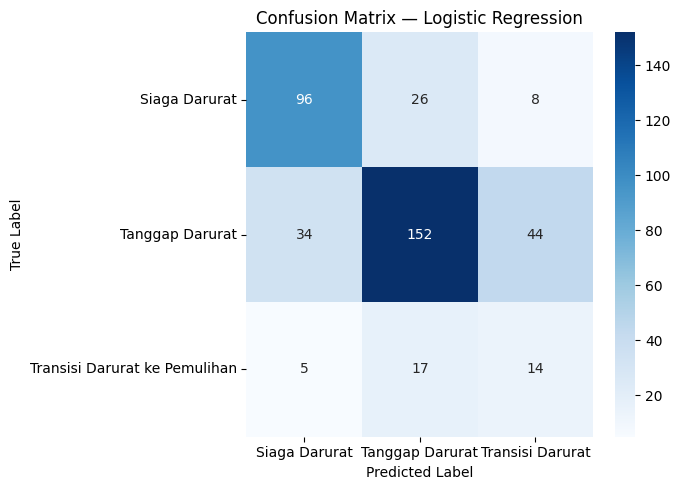

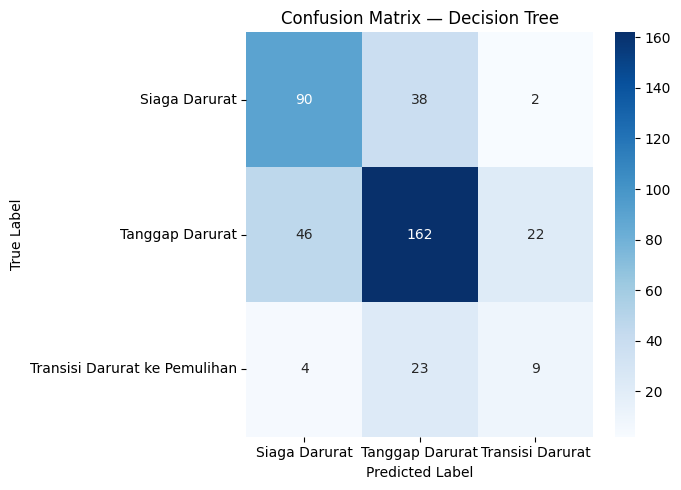

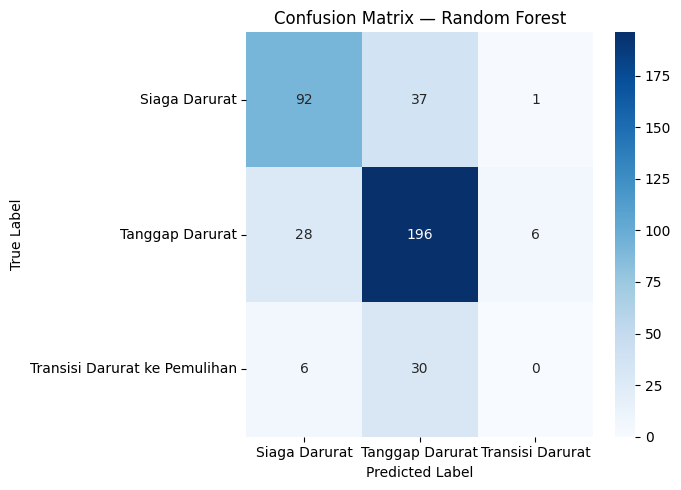

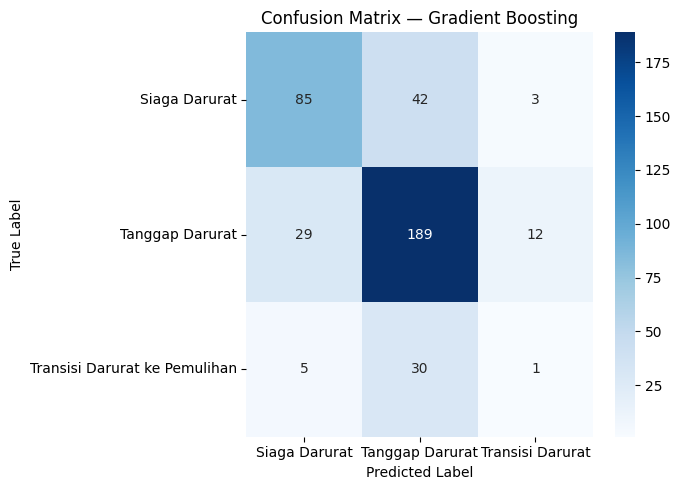

In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tambahkan Logistic Regression ke dictionary
predictions_cv_all = {
    "Logistic Regression": y_pred_lr_cv,
    **predictions_cv
}

for model_name, y_pred in predictions_cv_all.items():

    cm = confusion_matrix(
        y_train,
        y_pred,
        labels=[
            "Siaga Darurat",
            "Tanggap Darurat",
            "Transisi Darurat ke Pemulihan"
        ]
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Siaga Darurat",
            "Tanggap Darurat",
            "Transisi Darurat"
        ],
        yticklabels=[
            "Siaga Darurat",
            "Tanggap Darurat",
            "Transisi Darurat ke Pemulihan"
        ]
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Semua model baseline
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

test_results = []

for model_name, model_pipeline in models.items():

    print("\n" + "=" * 70)
    print(f"TEST SET EVALUATION — {model_name.upper()}")
    print("=" * 70)

    # Train model menggunakan training set
    model_pipeline.fit(X_train, y_train)

    # Prediksi test set
    y_pred = model_pipeline.predict(X_test)

    # Hitung metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision Macro": precision,
        "Recall Macro": recall,
        "F1 Macro": f1
    })

    # Classification report
    print(
        classification_report(
            y_test,
            y_pred,
            digits=4,
            zero_division=0
        )
    )


TEST SET EVALUATION — LOGISTIC REGRESSION
                               precision    recall  f1-score   support

                Siaga Darurat     0.7647    0.7879    0.7761        33
              Tanggap Darurat     0.8431    0.7544    0.7963        57
Transisi Darurat ke Pemulihan     0.4286    0.6667    0.5217         9

                     accuracy                         0.7576        99
                    macro avg     0.6788    0.7363    0.6981        99
                 weighted avg     0.7793    0.7576    0.7646        99


TEST SET EVALUATION — DECISION TREE
                               precision    recall  f1-score   support

                Siaga Darurat     0.7059    0.7273    0.7164        33
              Tanggap Darurat     0.7667    0.8070    0.7863        57
Transisi Darurat ke Pemulihan     0.6000    0.3333    0.4286         9

                     accuracy                         0.7374        99
                    macro avg     0.6908    0.6225    0.6438   

In [99]:
test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    "F1 Macro",
    ascending=False
).reset_index(drop=True)

print("HASIL EVALUASI TEST SET")
display(test_results_df)

HASIL EVALUASI TEST SET


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Logistic Regression,0.757576,0.678805,0.736310,0.698052
1,Decision Tree,0.737374,0.690850,0.622541,0.643771
2,Random Forest,0.787879,0.527083,0.575226,0.549992
3,Gradient Boosting,0.757576,0.525862,0.540670,0.530065


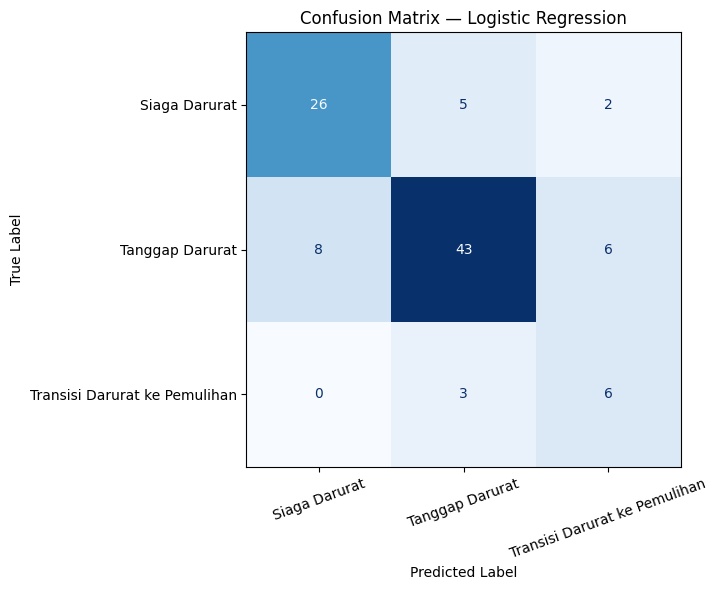

Confusion Matrix:
[[26  5  2]
 [ 8 43  6]
 [ 0  3  6]]


In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model Logistic Regression yang sudah dilatih pada training set
logistic_pipeline.fit(X_train, y_train)

# Prediksi test set
y_pred_lr_test = logistic_pipeline.predict(X_test)

# Label kelas
class_labels = [
    "Siaga Darurat",
    "Tanggap Darurat",
    "Transisi Darurat ke Pemulihan"
]

# Confusion matrix
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr_test,
    labels=class_labels
)

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=class_labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm_lr)

In [101]:
# Final model pipeline
final_model = logistic_pipeline

# Train final model menggunakan seluruh training set
final_model.fit(X_train, y_train)

print("Final model berhasil dilatih.")
print(f"Model: {final_model.named_steps['model']}")

Final model berhasil dilatih.
Model: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [102]:
# Evaluasi ulang final model pada test set
y_pred_final = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)
final_recall = recall_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)
final_f1 = f1_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)

print("FINAL MODEL EVALUATION")
print("=" * 50)
print(f"Accuracy       : {final_accuracy:.4f}")
print(f"Precision Macro: {final_precision:.4f}")
print(f"Recall Macro   : {final_recall:.4f}")
print(f"F1 Macro       : {final_f1:.4f}")

FINAL MODEL EVALUATION
Accuracy       : 0.7576
Precision Macro: 0.6788
Recall Macro   : 0.7363
F1 Macro       : 0.6981


In [103]:
import joblib
from pathlib import Path

# Folder untuk menyimpan model
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# Simpan seluruh pipeline
model_path = model_dir / "final_model.joblib"

joblib.dump(final_model, model_path)

print(f"Model berhasil disimpan: {model_path}")
print(f"Ukuran file: {model_path.stat().st_size / 1024:.2f} KB")

Model berhasil disimpan: models/final_model.joblib
Ukuran file: 16.20 KB


In [104]:
# Load kembali model
loaded_model = joblib.load(model_path)

print("Model berhasil di-load kembali.")
print(f"Model: {loaded_model.named_steps['model']}")

Model berhasil di-load kembali.
Model: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [105]:
# Contoh prediksi menggunakan model yang sudah di-load
sample_prediction = loaded_model.predict(X_test.iloc[:5])

print("Hasil prediksi:")
print(sample_prediction)

Hasil prediksi:
['Tanggap Darurat' 'Tanggap Darurat' 'Siaga Darurat' 'Tanggap Darurat'
 'Tanggap Darurat']
